## Mount & Path

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
 
# path_file  = '/content/drive/MyDrive/tesisugm/' #google colab
path_file = ''  # local

KOMPOSISI  = "lightgbm_smote"

## Load Features Module

In [2]:
import importlib.util, sys
 
# MODULE_PATH = "/content/drive/MyDrive/tesisugm/no-leakage/features.py"
MODULE_PATH = "features.py"

spec    = importlib.util.spec_from_file_location("features", MODULE_PATH)
features = importlib.util.module_from_spec(spec)
sys.modules["features"] = features
spec.loader.exec_module(features)
print("Features file   :", features.__file__)
print("Features version:", features.FEATURES_VERSION)

Features file   : features.py
Features version: Shami Extractor


## Imports

In [3]:
import os, gc, warnings, hashlib, itertools, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import hstack, csr_matrix, issparse
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, normalize
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report, confusion_matrix,
                                      silhouette_score)
from features import ShamiFeatureExtractor, clean_noise, clean_char
from imblearn.over_sampling import SMOTE

# Set environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

# Suppress all warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# Specific sklearn warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', module='sklearn.utils.validation')

# Your existing code
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', message='X does not have valid feature names')
 
warnings.filterwarnings("ignore")
print("Libraries loaded.")
 

Libraries loaded.


In [4]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# ── Global Theme ────────────────────────────────────────────
PALETTE   = ["#2D4A7A", "#4A90C4", "#6DB8A8", "#C4956A"]  # Jordan, Lebanon, Palestine, Syria
BG_COLOR  = "#F8F9FB"
CARD_COLOR= "#FFFFFF"
TEXT_DARK = "#1A2640"
TEXT_MID  = "#4A5568"
TEXT_LIGHT= "#8A97AA"
GRID_COLOR= "#E8ECF1"

def set_global_style():
    plt.rcParams.update({
        "figure.facecolor"  : BG_COLOR,
        "axes.facecolor"    : CARD_COLOR,
        "axes.edgecolor"    : GRID_COLOR,
        "axes.linewidth"    : 0.8,
        "axes.grid"         : True,
        "grid.color"        : GRID_COLOR,
        "grid.linewidth"    : 0.6,
        "grid.alpha"        : 0.8,
        "text.color"        : TEXT_DARK,
        "axes.labelcolor"   : TEXT_MID,
        "xtick.color"       : TEXT_MID,
        "ytick.color"       : TEXT_MID,
        "xtick.labelsize"   : 10,
        "ytick.labelsize"   : 10,
        "axes.labelsize"    : 11,
        "axes.titlesize"    : 13,
        "axes.titleweight"  : "bold",
        "axes.titlepad"     : 12,
        "font.family"       : "sans-serif",
        # "font.sans-serif"   : ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "axes.spines.top"   : False,
        "axes.spines.right" : False,
    })

set_global_style()

print("✅ Global style set!")

✅ Global style set!


## Inisiasi Path

In [5]:
# ROOT
BASE_DIR = os.path.join(path_file, "artifacts")

# GLOBAL SAVE
SAVE_DIR = os.path.join(BASE_DIR, "output")

# JOINT LOAD
JOINT_DIR = os.path.join(BASE_DIR, "joint_search")
JOINT_DOCS_DIR = os.path.join(JOINT_DIR, "docs")

# PER KOMPOSISI
KOMPOSISI_DIR = os.path.join(BASE_DIR, KOMPOSISI)

# SUB DIR
MODEL_DIR = os.path.join(KOMPOSISI_DIR, "model")
IMAGE_DIR = os.path.join(KOMPOSISI_DIR, "image")
DOCS_DIR  = os.path.join(KOMPOSISI_DIR, "docs")

# CREATE ALL
for d in [SAVE_DIR, KOMPOSISI_DIR, MODEL_DIR, IMAGE_DIR, DOCS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Semua path berhasil diinisialisasi!")

✅ Semua path berhasil diinisialisasi!


In [6]:
def save_and_show(name):
    path = os.path.join(IMAGE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

def global_image(name):
    path = os.path.join(SAVE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

## Data Preparation

In [7]:
df = pd.read_csv(f'../{path_file}dataset/shami_preprocessed_dataset_raw.csv')
df = (
    df.dropna(subset=["text", "label"])
      .rename(columns={"label": "country"})
)
df["clean_word"] = df["text"].apply(clean_noise)
df["clean_char"] = df["text"].apply(clean_char)
 
try:    display(df.head())
except: print(df.head())
display(df['country'].value_counts(normalize=True))

,text,country,clean_word,clean_char
0,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,Palestine,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...
1,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,Palestine,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...
2,اعملي اللي عليكي لوجه الله,Palestine,اعملي اللي عليكي لوجه الله,اعملي اللي عليكي لوجه الله
3,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,Palestine,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها
4,و هيا واياه بتزوجو هه,Palestine,و هيا واياه بتزوجو هه,و هيا واياه بتزوجو هه


country
Syria        0.569973
Lebanon      0.163464
Palestine    0.160641
Jordan       0.105922
Name: proportion, dtype: float64

### Class distribution plot 

🖼️ Saved: artifacts/output/class_distribution.png


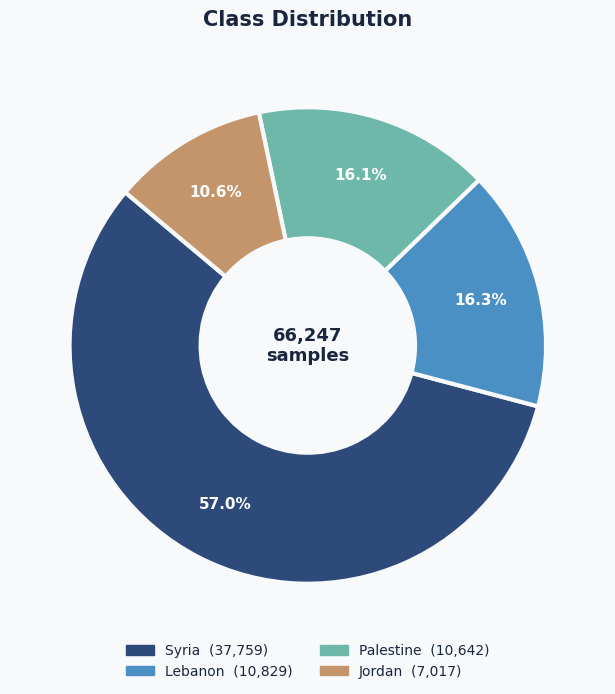

In [8]:
class_dist = df['country'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG_COLOR)
wedges, texts, autotexts = ax.pie(
    class_dist,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=BG_COLOR, linewidth=3),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# Centre label
ax.text(0, 0, f"{class_dist.sum():,}\nsamples",
        ha='center', va='center', fontsize=13,
        fontweight='bold', color=TEXT_DARK)

# Legend
legend_labels = [f"{c}  ({v:,})" for c, v in class_dist.items()]
patches = [mpatches.Patch(color=PALETTE[i], label=legend_labels[i])
           for i in range(len(class_dist))]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.08),
          ncol=2, frameon=False, fontsize=10)

ax.set_title("Class Distribution", fontsize=15, fontweight='bold',
             color=TEXT_DARK, pad=16)
fig.tight_layout()
global_image("class_distribution")

### Split

In [9]:
X = df[["text", "clean_word", "clean_char"]]
y = df["country"]
 
le          = LabelEncoder()
y_encoded   = le.fit_transform(y)
label_names = le.classes_
label_mapping   = {label: idx  for idx, label in enumerate(label_names)}
class_name_map  = {i: name     for i, name   in enumerate(label_names)}
print("Label mapping:", label_mapping)
 
from collections import Counter
 
def print_class_distribution(y_data, title):
    counter = Counter(y_data)
    print(f"\n=== {title} ===")
    total = len(y_data)
    for cls_id in sorted(counter.keys()):
        cls_name = class_name_map[cls_id]
        count    = counter[cls_id]
        print(f"{cls_id} ({cls_name}) : {count} ({count/total*100:.2f}%)")
    print("Total :", total)
 
print_class_distribution(y_encoded, "BEFORE SPLIT")
 
X_train_full, X_test,  y_train_full, y_test  = train_test_split(
    X, y_encoded, test_size=0.25, stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    stratify=y_train_full, random_state=42)
 
print_class_distribution(y_train, "TRAIN SET")
print_class_distribution(y_val,   "VALIDATION SET")
print_class_distribution(y_test,  "TEST SET")

Label mapping: {'Jordan': 0, 'Lebanon': 1, 'Palestine': 2, 'Syria': 3}

=== BEFORE SPLIT ===
0 (Jordan) : 7017 (10.59%)
1 (Lebanon) : 10829 (16.35%)
2 (Palestine) : 10642 (16.06%)
3 (Syria) : 37759 (57.00%)
Total : 66247

=== TRAIN SET ===
0 (Jordan) : 4210 (10.59%)
1 (Lebanon) : 6498 (16.35%)
2 (Palestine) : 6385 (16.06%)
3 (Syria) : 22655 (57.00%)
Total : 39748

=== VALIDATION SET ===
0 (Jordan) : 1053 (10.60%)
1 (Lebanon) : 1624 (16.34%)
2 (Palestine) : 1596 (16.06%)
3 (Syria) : 5664 (57.00%)
Total : 9937

=== TEST SET ===
0 (Jordan) : 1754 (10.59%)
1 (Lebanon) : 2707 (16.34%)
2 (Palestine) : 2661 (16.07%)
3 (Syria) : 9440 (57.00%)
Total : 16562


## Feature Extraction

In [10]:
CHI2_PCT             = 0.015
MI_PCT23             = 0.010
MI_PCT45             = 0.015
USE_OOF_INTERACTION = True   # flag diteruskan ke ShamiFeatureExtractor
 
split_hash = hashlib.md5(pd.util.hash_pandas_object(X_train["text"]).values).hexdigest()[:10]
base_signature = f"{features.FEATURES_VERSION}_{split_hash}"
base_cache_dir = os.path.join(path_file, "cache", base_signature)
os.makedirs(base_cache_dir, exist_ok=True)
 
feat_cache_key = (
    f"chi2_{CHI2_PCT}_mi23_{MI_PCT23}_mi45_{MI_PCT45}"
    f"_oof_inter_{int(USE_OOF_INTERACTION)}"
)
data_hash = hashlib.md5(df["text"].str.cat().encode()).hexdigest()[:8]

feat_cache_dir = os.path.join(
    base_cache_dir,
    feat_cache_key,
    data_hash
)

os.makedirs(feat_cache_dir, exist_ok=True)
print("Base signature :", base_signature)
print("Feat cache dir :", feat_cache_dir)
 
feat_path = os.path.join(base_cache_dir, "feature_extractor.pkl")
if os.path.exists(feat_path):
    print("✅ Loading base extractor...")
    feat = joblib.load(feat_path)
else:
    print("⚙️ Building base extractor (MI fit bisa makan waktu 2-5 menit)...")
    feat = ShamiFeatureExtractor(
        chi2_pct=CHI2_PCT,
        mi_pct23=MI_PCT23,
        mi_pct45=MI_PCT45,
        use_oof_lr=True,
        use_oof_interaction=USE_OOF_INTERACTION, 
    )
    feat.fit(X_train, y_train) 
    joblib.dump(feat, feat_path)
print("Base extractor ready.")

Base signature : Shami Extractor_0890ac2785
Feat cache dir : cache/Shami Extractor_0890ac2785/chi2_0.015_mi23_0.01_mi45_0.015_oof_inter_1/6ace3dc3
✅ Loading base extractor...
Base extractor ready.


### Update k

In [11]:
feat.update_chi2_pct(CHI2_PCT)
feat.update_mi_pct(new_pct23=MI_PCT23, new_pct45=MI_PCT45)
 
# ---- Info dimensi ----
print("\nMI info     :", feat.mi_info)
print("Block sizes :", feat.block_sizes)

[update] chi2_pct=1.50% -> chi2_k=2,420
[update] mi_pct23=1.00% -> mi_k23=500
[update] mi_pct45=1.50% -> mi_k45=2,650

MI info     : {'chi2_pct': 0.015, 'chi2_k_eff': 2420, 'mi_pct23': 0.01, 'mi_k23_eff': 500, 'char23_vocab': 10964, 'char23_selected': 500, 'mi_pct45': 0.015, 'mi_k45_eff': 2650, 'char45_vocab': 176676, 'char45_selected': 2650}
Block sizes : {'lexical': 2420, 'char_mi23': 500, 'char_mi45': 2650, 'doc_stats': 7, 'stopword': 2, 'morph': 26, 'morph_inter': 8, 'colloc_dom': 1, 'nbsvm': 4, 'oof_lr': 8, 'oof_svm': 8, 'oof_interactions': 10}


### Lexical Info

In [12]:
dims = {
    "tfidf_wL_uni": len(feat.tfidf_wL_uni.vocabulary_),
    "tfidf_wL_23" : len(feat.tfidf_wL_23.vocabulary_),
    "tfidf_wA_uni": len(feat.tfidf_wA_uni.vocabulary_),
    "tfidf_wA_23" : len(feat.tfidf_wA_23.vocabulary_),
    "tfidf_char"  : len(feat.tfidf_char.vocabulary_),
    "bm25_word"   : len(feat.bm25w.cv.vocabulary_),
    "bm25_char"   : len(feat.bm25c.cv.vocabulary_),
}
print("\n==============================")
print("LEXICAL FEATURES BEFORE CHI2")
print("==============================")
for k, v in dims.items():
    print(f"{k:15s}: {v:,}")
print(f"\nLEXICAL total  : {sum(dims.values()):,}")
 
ranges = {}
start  = 0
for name, size in dims.items():
    ranges[name] = (start, start + size)
    start += size
counts = {k: 0 for k in dims}
for c in feat._chi2_cols:
    for name, (s, e) in ranges.items():
        if s <= c < e:
            counts[name] += 1
            break
print("\n==============================")
print("LEXICAL FEATURES AFTER CHI2")
print("==============================")
for k, v in counts.items():
    print(f"{k:15s}: {v:,}")
print(f"\nTotal chi2 selected: {len(feat._chi2_cols):,}")


LEXICAL FEATURES BEFORE CHI2
tfidf_wL_uni   : 19,234
tfidf_wL_23    : 19,234
tfidf_wA_uni   : 19,226
tfidf_wA_23    : 19,226
tfidf_char     : 34,631
bm25_word      : 40,562
bm25_char      : 9,272

LEXICAL total  : 161,385

LEXICAL FEATURES AFTER CHI2
tfidf_wL_uni   : 115
tfidf_wL_23    : 115
tfidf_wA_uni   : 115
tfidf_wA_23    : 115
tfidf_char     : 843
bm25_word      : 316
bm25_char      : 801

Total chi2 selected: 2,420


In [13]:
print("\n==============================")
print("CHAR FEATURES BEFORE MI")
print("==============================")

print(f"char_2_3 vocab: {feat._X_char23_tr.shape[1]:,}")
print(f"char_4_5 vocab: {feat._X_char45_tr.shape[1]:,}")
print(f"Total char    : {feat._X_char23_tr.shape[1] + feat._X_char45_tr.shape[1]:,}")

print("\n==============================")
print("CHAR FEATURES AFTER MI")
print("==============================")

print(f"char_mi23: {feat._mi_sel23.n_selected:,}")
print(f"char_mi45: {feat._mi_sel45.n_selected:,}")
print(f"Total MI  : {feat._mi_sel23.n_selected + feat._mi_sel45.n_selected:,}")


CHAR FEATURES BEFORE MI
char_2_3 vocab: 10,964
char_4_5 vocab: 176,676
Total char    : 187,640

CHAR FEATURES AFTER MI
char_mi23: 500
char_mi45: 2,650
Total MI  : 3,150


### Build / Load Feature Matrices

In [14]:
xtr_path  = os.path.join(feat_cache_dir, "Xtr_feat.pkl")
xval_path = os.path.join(feat_cache_dir, "Xval_feat.pkl")
xte_path  = os.path.join(feat_cache_dir, "Xte_feat.pkl")
ytr_path  = os.path.join(feat_cache_dir, "y_train.pkl")
yval_path = os.path.join(feat_cache_dir, "y_val.pkl")
yte_path  = os.path.join(feat_cache_dir, "y_test.pkl")
 
if all(os.path.exists(p) for p in [xtr_path, xval_path, xte_path,
                                    ytr_path, yval_path, yte_path]):
    print("✅ Loading feature matrices from cache...")
    Xtr_feat  = joblib.load(xtr_path)
    Xval_feat = joblib.load(xval_path)
    Xte_feat  = joblib.load(xte_path)
    y_train   = joblib.load(ytr_path)
    y_val     = joblib.load(yval_path)
    y_test    = joblib.load(yte_path)
else:
    print("⚙️ Building feature matrices...")
    # feat.transform() output:
    # [lexical_chi2 | char_mi23 | char_mi45 | structural | oof_lr | oof_svm | oof_interactions]
    Xtr_feat  = feat.transform(X_train, is_train=True)   
    Xval_feat = feat.transform(X_val,   is_train=False)  
    Xte_feat  = feat.transform(X_test,  is_train=False)  
    gc.collect()
    joblib.dump(Xtr_feat,  xtr_path)
    joblib.dump(Xval_feat, xval_path)
    joblib.dump(Xte_feat,  xte_path)
    joblib.dump(y_train,   ytr_path)
    joblib.dump(y_val,     yval_path)
    joblib.dump(y_test,    yte_path)
 
print(f"Train shape : {Xtr_feat.shape}")
print(f"Val shape   : {Xval_feat.shape}")
print(f"Test shape  : {Xte_feat.shape}")

✅ Loading feature matrices from cache...
Train shape : (39748, 5644)
Val shape   : (9937, 5644)
Test shape  : (16562, 5644)


### Block Ablation Utilities

In [15]:
def build_block_slices(block_sizes):
    slices = {}
    start  = 0
    for name, size in block_sizes.items():
        slices[name] = (start, start + size)
        start += size
    return slices
 
def drop_blocks(X, block_slices, drop_list):
    keep_cols = []
    for name, (s, e) in block_slices.items():
        if name not in drop_list:
            keep_cols.extend(range(s, e))
        else:
            print(f"  Dropping block: {name}  size={e - s:,}")
    keep_cols = np.array(keep_cols)
    return X[:, keep_cols], keep_cols
 
block_slices = build_block_slices(feat.block_sizes)
print("\nBlock slices:")
for k, (s, e) in block_slices.items():
    print(f"  {k:20s}: cols {s:5d}–{e:5d}  ({e - s:,})")


Block slices:
  lexical             : cols     0– 2420  (2,420)
  char_mi23           : cols  2420– 2920  (500)
  char_mi45           : cols  2920– 5570  (2,650)
  doc_stats           : cols  5570– 5577  (7)
  stopword            : cols  5577– 5579  (2)
  morph               : cols  5579– 5605  (26)
  morph_inter         : cols  5605– 5613  (8)
  colloc_dom          : cols  5613– 5614  (1)
  nbsvm               : cols  5614– 5618  (4)
  oof_lr              : cols  5618– 5626  (8)
  oof_svm             : cols  5626– 5634  (8)
  oof_interactions    : cols  5634– 5644  (10)


In [16]:
# ---- Ubah drop_list untuk ablasi ----
drop_list = []
if drop_list:
    print("\nDropping blocks:", drop_list)
    Xtr_sel,  _         = drop_blocks(Xtr_feat,  block_slices, drop_list)
    Xval_sel, _         = drop_blocks(Xval_feat, block_slices, drop_list)
    Xte_sel,  kept_cols = drop_blocks(Xte_feat,  block_slices, drop_list)
else:
    print("\nNo block dropped.")
    Xtr_sel   = Xtr_feat
    Xval_sel  = Xval_feat
    Xte_sel   = Xte_feat
    kept_cols = np.arange(Xtr_feat.shape[1])


No block dropped.


In [17]:
# ============================================================
## SVD (opsional, default OFF)
# ============================================================
USE_SVD = False
if USE_SVD:
    from sklearn.decomposition import TruncatedSVD
    print("\nApplying SVD compression...")
    svd      = TruncatedSVD(n_components=200, random_state=42)
    Xtr_sel  = svd.fit_transform(Xtr_sel)
    Xval_sel = svd.transform(Xval_sel)
    Xte_sel  = svd.transform(Xte_sel)
    print(f"Train: {Xtr_sel.shape}")
else:
    print("Skipping SVD (recommended for LightGBM)")
    print(f"Train: {Xtr_sel.shape}")

Skipping SVD (recommended for LightGBM)
Train: (39748, 5644)


## SMOTE

### Load artifacts dari joint_search

In [18]:
from imblearn.over_sampling import SMOTE

best_params          = joblib.load(os.path.join(SAVE_DIR, "lightgbm_original_best_params.pkl"))
BEST_SAMPLING_STRATEGY = joblib.load(os.path.join(SAVE_DIR, "best_sampling_strategy.pkl"))
K_FIXED              = joblib.load(os.path.join(SAVE_DIR, "best_k_neighbors.pkl"))

print(f"✅ best_params            : {best_params}")
print(f"✅ BEST_SAMPLING_STRATEGY : {BEST_SAMPLING_STRATEGY}")
print(f"✅ K_FIXED                : {K_FIXED}")

class_counts = Counter(y_train)
maj_count    = max(class_counts.values())
min_count    = min(class_counts.values())
k_safe       = max(1, min(K_FIXED, min_count - 1))

✅ best_params            : {'num_leaves': 25, 'colsample_bytree': 0.4, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'min_child_samples': 50}
✅ BEST_SAMPLING_STRATEGY : {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}
✅ K_FIXED                : 5


### Helper Functions Visualisasi


In [19]:
def apply_plot_style(ax):
    """Menghindari pengulangan setting style di setiap subplot."""
    ax.set_facecolor(CARD_COLOR)
    ax.grid(color=GRID_COLOR, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)

def add_bottom_legend(fig, text, y_pos=-0.02):
    """Menghindari pengulangan penulisan legend di bawah figure."""
    fig.text(0.5, y_pos, text, ha="center", fontsize=9, color=TEXT_MID)

# ── Setup alias & Legend ──────────────────────────────────────
def make_class_alias(label_names, cls_indices, n_char=1):
    alias = {}
    used = set()
    for c in cls_indices:
        name = label_names[c]
        short = name[:n_char]
        i = n_char
        while short in used:
            i += 1
            short = name[:i]
        alias[c] = short
        used.add(short)
    return alias

def shorten_combo(combo_str, cls_indices, cls_short, label_names):
    for c in cls_indices:
        combo_str = combo_str.replace(f"{label_names[c]}=", f"{cls_short[c]}=")
    return combo_str

maj_class   = max(class_counts, key=class_counts.get)
cls_indices = sorted([cls for cls in class_counts.keys() if cls != maj_class])
all_classes = list(range(len(label_names)))
cls_short = make_class_alias(label_names, all_classes, n_char=1)
idx_to_name = {c: label_names[c] for c in cls_indices}

legend_text = " | ".join([f"{cls_short[c]} = {label_names[c]}" for c in cls_indices])

### Apply SMOTE dengan Best Ratio

In [20]:
# ── Apply SMOTE ───────────────────────────────────────────────
print(f"\nApplying SMOTE...")
print(f"  sampling_strategy : {BEST_SAMPLING_STRATEGY}")
print(f"  k_neighbors       : {k_safe}")

smote = SMOTE(
    sampling_strategy = BEST_SAMPLING_STRATEGY,
    k_neighbors       = k_safe,
    random_state      = 42,
)
Xtr_os, ytr_os = smote.fit_resample(Xtr_sel, y_train)

print(f"\nBefore SMOTE : {dict(class_counts)}")
print(f"After  SMOTE : {dict(Counter(ytr_os))}")

joblib.dump((Xtr_os, ytr_os), os.path.join(SAVE_DIR, f"{KOMPOSISI}_smote_data.pkl"))
print(f"✅ Data SMOTE tersimpan di: {KOMPOSISI}_smote_data.pkl")


Applying SMOTE...
  sampling_strategy : {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}
  k_neighbors       : 5

Before SMOTE : {np.int64(3): 22655, np.int64(1): 6498, np.int64(2): 6385, np.int64(0): 4210}
After  SMOTE : {np.int64(3): 22655, np.int64(1): 19423, np.int64(2): 19401, np.int64(0): 7899}
✅ Data SMOTE tersimpan di: lightgbm_smote_smote_data.pkl


### Visualisasi Distribusi Sebelum vs Sesudah SMOTE

🖼️ Saved: artifacts/lightgbm_smote/image/class_distribution_smote.png


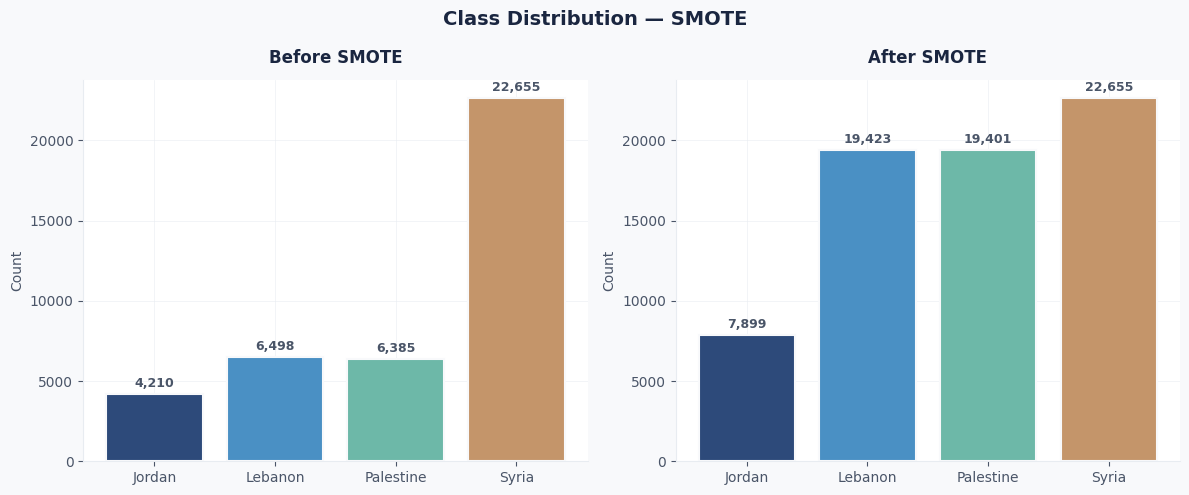

In [21]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde
from sklearn.preprocessing import normalize
import matplotlib.gridspec as gridspec

# ── Visualisasi Class Distribution ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG_COLOR)

for ax, (y_data, title) in zip(axes, [(y_train, "Before SMOTE"), (ytr_os, "After SMOTE")]):
    counts_plot = [np.sum(y_data == i) for i in range(len(label_names))]
    bars = ax.bar(label_names, counts_plot, color=PALETTE, edgecolor=BG_COLOR, linewidth=1.5)
    
    for bar, val in zip(bars, counts_plot):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts_plot)*0.01,
                f"{val:,}", ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=TEXT_MID)
        
    ax.set_title(title, fontsize=12, fontweight='bold', color=TEXT_DARK)
    ax.set_ylabel("Count", fontsize=10, color=TEXT_MID)
    apply_plot_style(ax)

fig.suptitle("Class Distribution — SMOTE", fontsize=14, fontweight='bold', color=TEXT_DARK)
fig.tight_layout()
save_and_show("class_distribution_smote")

## Cluster Analysis (Dens)


Computing t-SNE embeddings Before vs After SMOTE... (~5-8 menit)
  → Before SMOTE... 

done
🖼️ Saved: artifacts/lightgbm_smote/image/cluster_density_before.png


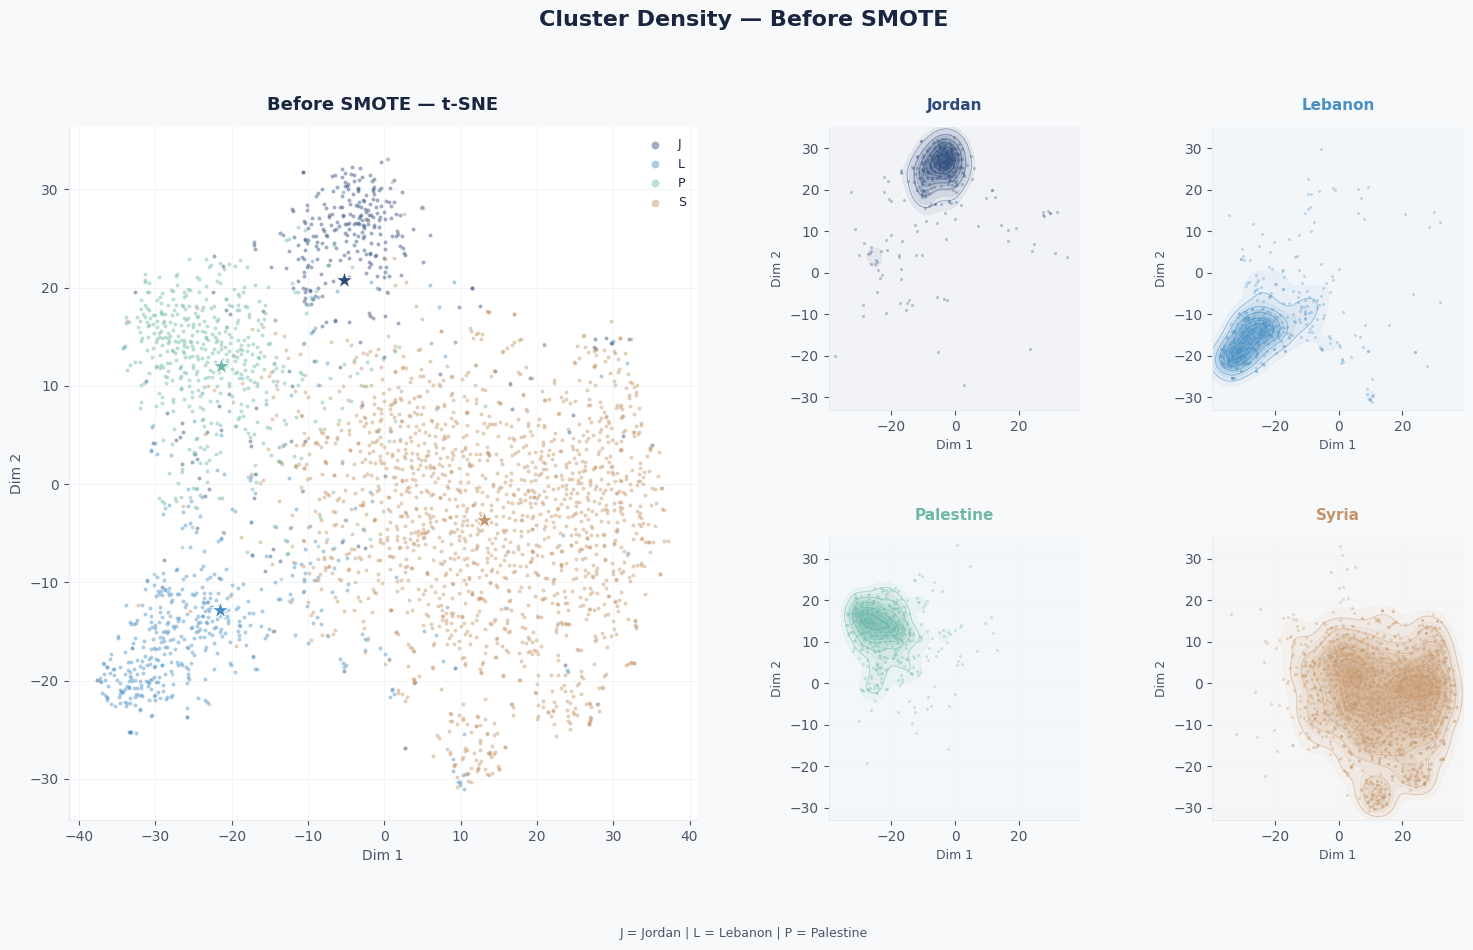

  → After SMOTE... done
🖼️ Saved: artifacts/lightgbm_smote/image/cluster_density_after.png


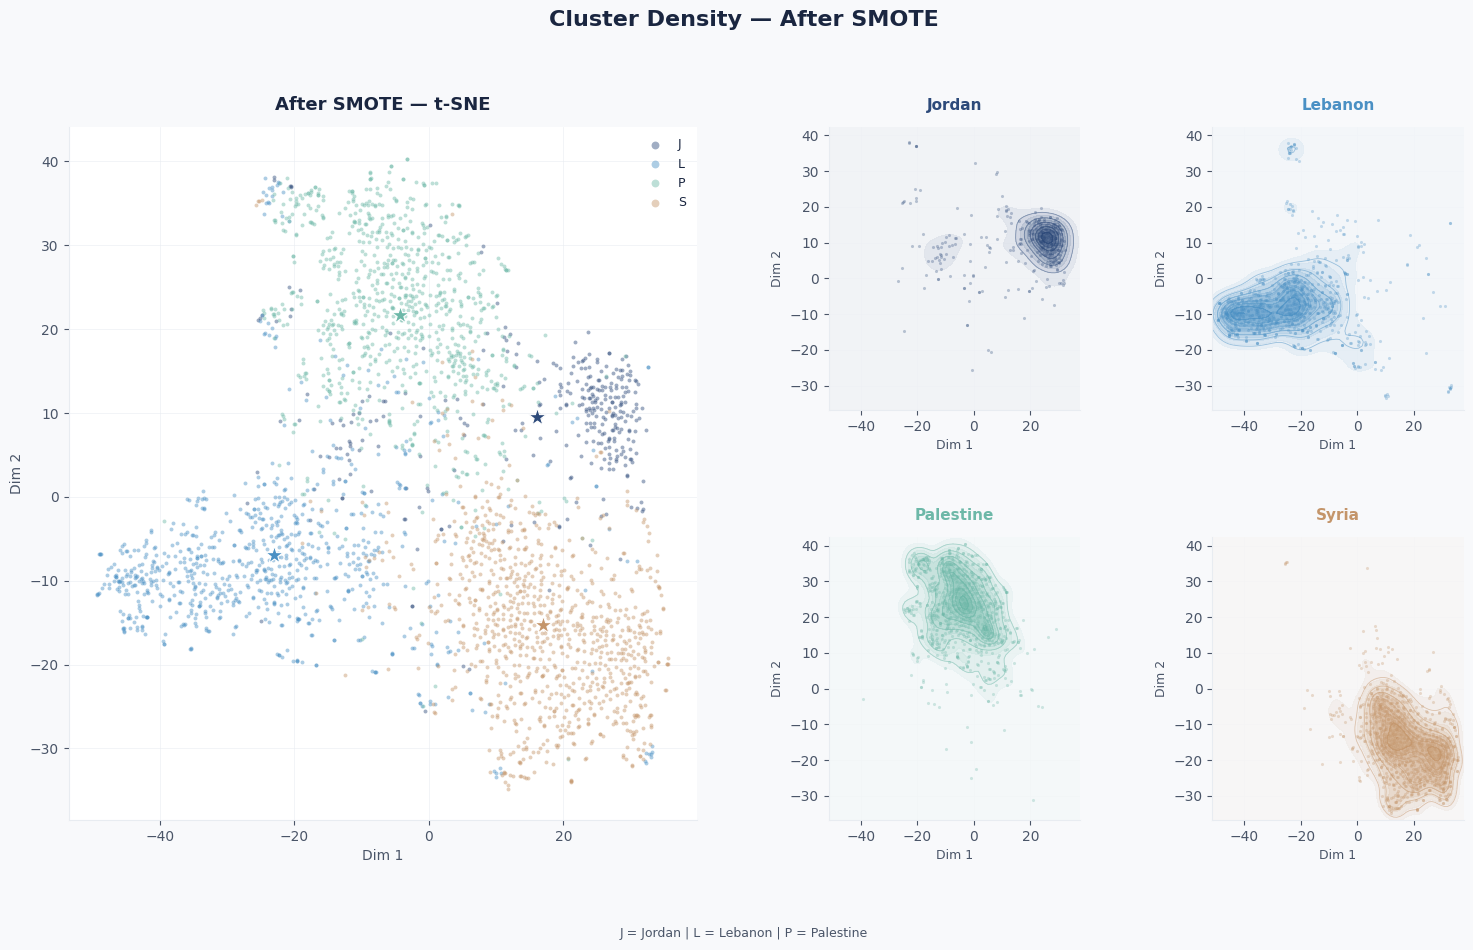

✅ Cluster density before vs after SMOTE tersimpan!


In [22]:
# ── Cluster Density Visualization ───────────────────────────
def get_2d_embedding(X, y, n_sample=3000, random_state=42):
    """Reduce ke 2D via SVD → t-SNE."""
    import scipy.sparse as sp
    if sp.issparse(X): X = X.tocsr()
    if X.shape[0] > n_sample:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(X.shape[0], n_sample, replace=False)
        X, y = X[idx], y[idx]
        
    Xn = normalize(X, norm="l2")
    n_comp = min(50, Xn.shape[1] - 1)
    Xr = TruncatedSVD(n_components=n_comp, random_state=random_state).fit_transform(Xn)
    X2d = TSNE(n_components=2, perplexity=40, metric="cosine", random_state=random_state, init="pca", learning_rate="auto").fit_transform(Xr)
    return X2d, np.asarray(y)

def plot_cluster_density(X2d, y, label_names, title, palette, ax_scatter, ax_kde_list):
    classes = np.unique(y)

    # ── Scatter ──
    apply_plot_style(ax_scatter)
    for i, c_raw in enumerate(classes):
        c = int(c_raw)
        mask = y == c_raw
        ax_scatter.scatter(X2d[mask, 0], X2d[mask, 1], c=palette[i], label=cls_short[c], s=8, alpha=0.45, linewidths=0)
        ax_scatter.scatter(X2d[mask, 0].mean(), X2d[mask, 1].mean(), c=palette[i], s=180, marker='*', edgecolors='white', linewidths=0.8, zorder=5)

    ax_scatter.set_title(f"{title} — t-SNE", fontsize=13, fontweight='bold', color=TEXT_DARK)
    ax_scatter.legend(fontsize=9, frameon=False, markerscale=2, loc='best')
    ax_scatter.set_xlabel("Dim 1", fontsize=10, color=TEXT_MID)
    ax_scatter.set_ylabel("Dim 2", fontsize=10, color=TEXT_MID)

    # ── KDE per kelas ──
    for i, (c_raw, ax_k) in enumerate(zip(classes, ax_kde_list)):
        apply_plot_style(ax_k)
        c, mask = int(c_raw), y == c_raw
        pts, color = X2d[mask], palette[i]

        try:
            kde = gaussian_kde(pts.T, bw_method=0.25)
            xmin, xmax = X2d[:, 0].min()-2, X2d[:, 0].max()+2
            ymin, ymax = X2d[:, 1].min()-2, X2d[:, 1].max()+2
            xx, yy = np.mgrid[xmin:xmax:80j, ymin:ymax:80j]
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            ax_k.contourf(xx, yy, zz, levels=12, cmap=LinearSegmentedColormap.from_list("", ["#F8F9FB", color], N=256), alpha=0.85)
            ax_k.contour(xx, yy, zz, levels=6, colors=[color], linewidths=0.6, alpha=0.5)
        except Exception:
            pass

        ax_k.scatter(pts[:, 0], pts[:, 1], c=color, s=5, alpha=0.3, linewidths=0)
        ax_k.set_title(label_names[c], fontsize=11, fontweight='bold', color=color)
        ax_k.set_xlabel("Dim 1", fontsize=9, color=TEXT_MID)
        ax_k.set_ylabel("Dim 2", fontsize=9, color=TEXT_MID)

print("\nComputing t-SNE embeddings Before vs After SMOTE... (~5-8 menit)")

# Gunakan after_dict agar kelas mayoritas tetap ter-print di judul
splits = [
    (Xtr_sel, y_train, "Before SMOTE"),
    (Xtr_os,  ytr_os,  "After SMOTE"),
]

for X_sp, y_sp, name in splits:
    print(f"  → {name.replace(chr(10), ' ')}...", end=" ", flush=True) # Hapus newline cuma buat nge-print status log
    X2d, y2d = get_2d_embedding(X_sp, y_sp, n_sample=3000)
    print("done")

    fig = plt.figure(figsize=(18, 9), facecolor=BG_COLOR)
    fig.suptitle(f"Cluster Density — {name.split(chr(10))[0]}", fontsize=16, fontweight='bold', color=TEXT_DARK, y=1.01)

    gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[2.5, 1, 1], hspace=0.45, wspace=0.35)
    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_kde_list = [fig.add_subplot(gs[i // 2, 1 + i % 2]) for i in range(len(np.unique(y2d)))]

    plot_cluster_density(X2d, y2d, label_names, name.split(chr(10))[0], PALETTE, ax_scatter, ax_kde_list)

    add_bottom_legend(fig, legend_text)
    fig.tight_layout()
    
    fname = "cluster_density_before" if "Before" in name else "cluster_density_after"
    save_and_show(fname)

print("✅ Cluster density before vs after SMOTE tersimpan!")

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, f1_score, accuracy_score, classification_report, confusion_matrix
from scipy.sparse import issparse
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ==============================================================================
# Cluster Analysis — Before vs After Oversampling
# ==============================================================================

def compute_cluster_metrics_full(X, y, label_names, title=""):
    """
    Hitung semua metrik cluster di feature space asli (bukan t-SNE).
    """
    if issparse(X):
        X = X.tocsr()

    # Subsample untuk efisiensi komputasi
    if X.shape[0] > 5000:
        rng = np.random.default_rng(42)
        idx = rng.choice(X.shape[0], 5000, replace=False)
        X_s, y_s = X[idx], np.asarray(y)[idx]
    else:
        X_s, y_s = X, np.asarray(y)

    Xn = normalize(X_s, norm="l2")
    classes = np.unique(y_s)
    C = len(classes)

    # ── Silhouette ──────────────────────────────────────────
    sil = silhouette_score(Xn, y_s, metric="cosine")

    # ── Centroids ───────────────────────────────────────────
    centroids = []
    for c in classes:
        mu = np.asarray(Xn[y_s == c].mean(axis=0)).ravel()
        mu = mu / (np.linalg.norm(mu) + 1e-9)
        centroids.append(mu)
    centroids = np.vstack(centroids)

    # ── Inter-cluster distance (mean centroid dist) ──────────
    inter_dists = []
    inter_pairs = {}
    for i in range(C):
        for j in range(i+1, C):
            d = 1 - np.dot(centroids[i], centroids[j])
            inter_dists.append(d)
            inter_pairs[f"{label_names[classes[i]]} ↔ {label_names[classes[j]]}"] = round(d, 4)
            
    mean_inter = np.mean(inter_dists)
    min_inter  = np.min(inter_dists)

    # ── Intra-cluster compactness (mean dist ke centroid) ────
    intra_per_class = {}
    for i, c in enumerate(classes):
        Xc = normalize(np.asarray(Xn[y_s == c].todense() if issparse(Xn) else Xn[y_s == c]), norm="l2")
        dists = 1 - (Xc @ centroids[i])
        intra_per_class[label_names[c]] = {
            "mean" : round(float(np.mean(dists)), 4),
            "std"  : round(float(np.std(dists)),  4),
            "n"    : int(np.sum(y_s == c)),
        }
    mean_intra = np.mean([v["mean"] for v in intra_per_class.values()])

    # ── Davies-Bouldin Index & Calinski-Harabasz ────────────
    X_arr = Xn.toarray() if issparse(Xn) else Xn
    
    try:
        db_idx = davies_bouldin_score(X_arr, y_s)
    except Exception:
        db_idx = float('nan')

    try:
        ch_idx = calinski_harabasz_score(X_arr, y_s)
    except Exception:
        ch_idx = float('nan')

    # ── Overlap score ────────────────────────────────────────
    overlap = mean_intra / (mean_intra + mean_inter + 1e-9)

    return {
        "title"             : title,
        "n_samples"         : X_s.shape[0],
        "silhouette"        : round(sil, 4),
        "mean_inter_dist"   : round(mean_inter, 4),
        "min_inter_dist"    : round(min_inter,  4),
        "mean_intra_dist"   : round(mean_intra, 4),
        "overlap_score"     : round(overlap, 4),
        "davies_bouldin"    : round(db_idx, 4),
        "calinski_harabasz" : round(ch_idx, 1),
        "inter_pairs"       : inter_pairs,
        "intra_per_class"   : intra_per_class,
    }

# ── Hitung metrik ─────────────────────────────────────────────
print("\nComputing cluster metrics (di feature space asli)...")

metrics_before = compute_cluster_metrics_full(Xtr_sel, y_train, label_names, title="Before SMOTE")
metrics_after  = compute_cluster_metrics_full(Xtr_os, ytr_os, label_names, title="After SMOTE")

all_metrics = [metrics_before, metrics_after]

# ── Print ringkasan ───────────────────────────────────────────
def print_cluster_summary(m):
    print(f"\n{'='*55}")
    print(f"  {m['title']}")
    print(f"{'='*55}")
    print(f"  Samples           : {m['n_samples']:,}")
    print(f"  Silhouette Score  : {m['silhouette']:+.4f}  {'↑ better' if m['silhouette'] > 0 else '↓ overlap'}")
    print(f"  Mean Inter-dist   : {m['mean_inter_dist']:.4f}  (antar centroid, higher=lebih terpisah)")
    print(f"  Min  Inter-dist   : {m['min_inter_dist']:.4f}  (pasangan paling mirip)")
    print(f"  Mean Intra-dist   : {m['mean_intra_dist']:.4f}  (kompaktness, lower=lebih padat)")
    print(f"  Overlap Score     : {m['overlap_score']:.4f}  (lower=lebih terpisah)")
    print(f"  Davies-Bouldin    : {m['davies_bouldin']:.4f}  (lower=better)")
    print(f"  Calinski-Harabasz : {m['calinski_harabasz']:.1f}  (higher=better)")

    print(f"\n  Inter-class distance (cosine):")
    for pair, d in sorted(m['inter_pairs'].items(), key=lambda x: x[1]):
        print(f"    {pair:35s}: {d:.4f}  {'█' * int(d * 20)}")

    print(f"\n  Intra-class compactness (mean dist ke centroid):")
    for cls, v in m['intra_per_class'].items():
        print(f"    {cls:12s}: mean={v['mean']:.4f} ± {v['std']:.4f}  n={v['n']:,}  {'█' * int(v['mean'] * 30)}")

for m in all_metrics:
    print_cluster_summary(m)

# ── Delta analysis ────────────────────────────────────────────
mb, ma = metrics_before, metrics_after

print(f"\n{'='*55}\n  DELTA: After - Before Oversampling\n{'='*55}")

delta_items = [
    ("Silhouette",        mb['silhouette'],        ma['silhouette'],        True),
    ("Mean Inter-dist",   mb['mean_inter_dist'],   ma['mean_inter_dist'],   True),
    ("Mean Intra-dist",   mb['mean_intra_dist'],   ma['mean_intra_dist'],   False),
    ("Overlap Score",     mb['overlap_score'],     ma['overlap_score'],     False),
    ("Davies-Bouldin",    mb['davies_bouldin'],    ma['davies_bouldin'],    False),
    ("Calinski-Harabasz", mb['calinski_harabasz'], ma['calinski_harabasz'], True),
]

for name, vb, va, higher_better in delta_items:
    delta = va - vb
    is_improved = (delta > 0) == higher_better
    sign = "✅" if is_improved else "⚠️"
    print(f"  {name:22s}: {vb:.4f} → {va:.4f}  (Δ={delta:+.4f})  {sign}")

# ── Simpan ke CSV ─────────────────────────────────────────────
rows = []
for m in all_metrics:
    row = {k: v for k, v in m.items() if k not in ("inter_pairs", "intra_per_class")}
    for cls, v in m["intra_per_class"].items():
        row.update({f"intra_{cls}_mean": v["mean"], f"intra_{cls}_std": v["std"], f"intra_{cls}_n": v["n"]})
    rows.append(row)

pd.DataFrame(rows).to_csv(os.path.join(DOCS_DIR, f"{KOMPOSISI}_cluster_metrics.csv"), index=False)
print(f"\n✅ Saved: {KOMPOSISI}_cluster_metrics.csv")


Computing cluster metrics (di feature space asli)...

  Before SMOTE
  Samples           : 5,000
  Silhouette Score  : +0.2794  ↑ better
  Mean Inter-dist   : 0.0416  (antar centroid, higher=lebih terpisah)
  Min  Inter-dist   : 0.0216  (pasangan paling mirip)
  Mean Intra-dist   : 0.0400  (kompaktness, lower=lebih padat)
  Overlap Score     : 0.4900  (lower=lebih terpisah)
  Davies-Bouldin    : 2.2041  (lower=better)
  Calinski-Harabasz : 612.8  (higher=better)

  Inter-class distance (cosine):
    Jordan ↔ Palestine                 : 0.0216  
    Jordan ↔ Syria                     : 0.0237  
    Palestine ↔ Syria                  : 0.0396  
    Lebanon ↔ Palestine                : 0.0519  █
    Jordan ↔ Lebanon                   : 0.0531  █
    Lebanon ↔ Syria                    : 0.0599  █

  Intra-class compactness (mean dist ke centroid):
    Jordan      : mean=0.0410 ± 0.0512  n=549  █
    Lebanon     : mean=0.0602 ± 0.0468  n=820  █
    Palestine   : mean=0.0327 ± 0.0325  n=813

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_metric_silhouette.png


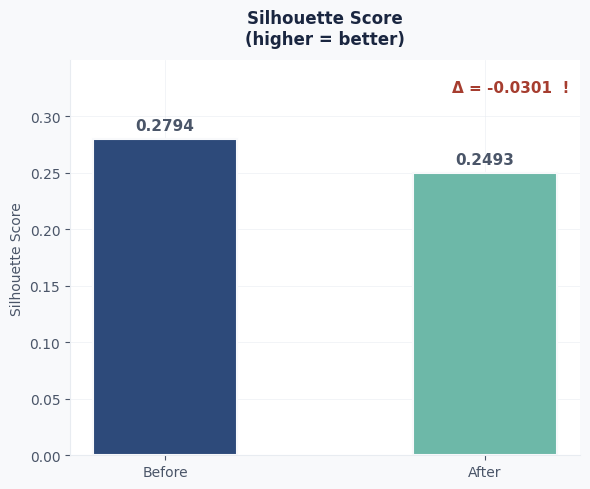

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_metric_mean_inter_dist.png


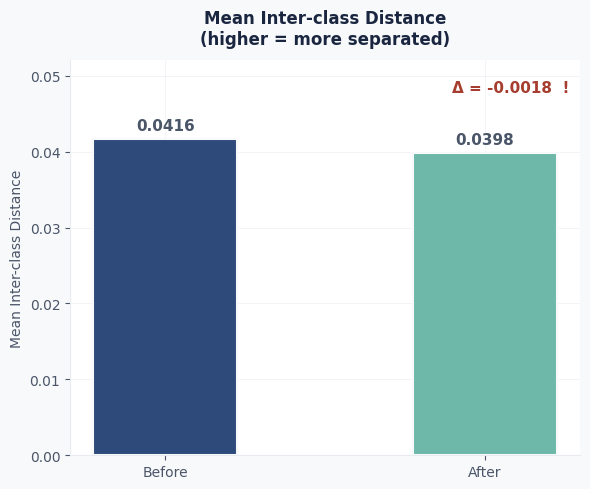

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_metric_mean_intra_dist.png


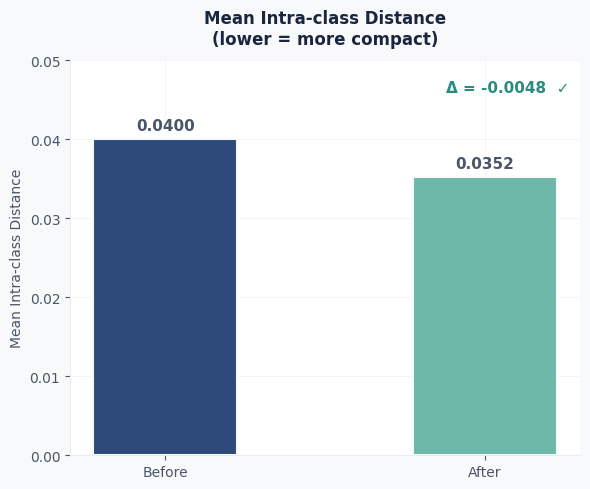

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_metric_overlap_score.png


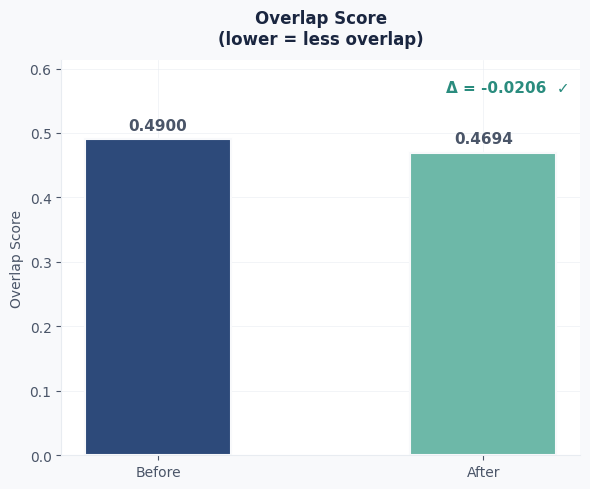

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_metric_davies_bouldin.png


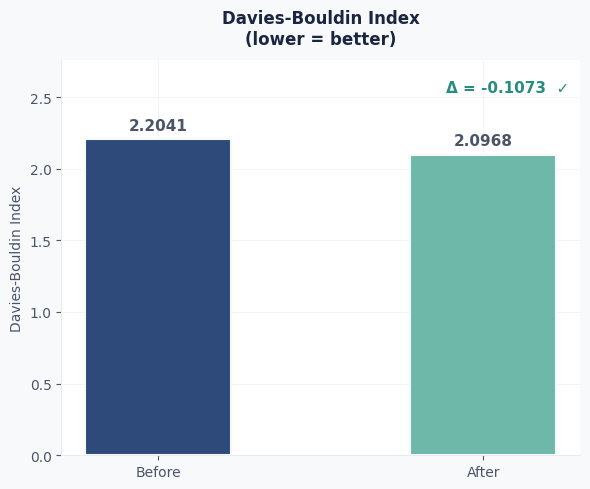

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_metric_calinski_harabasz.png


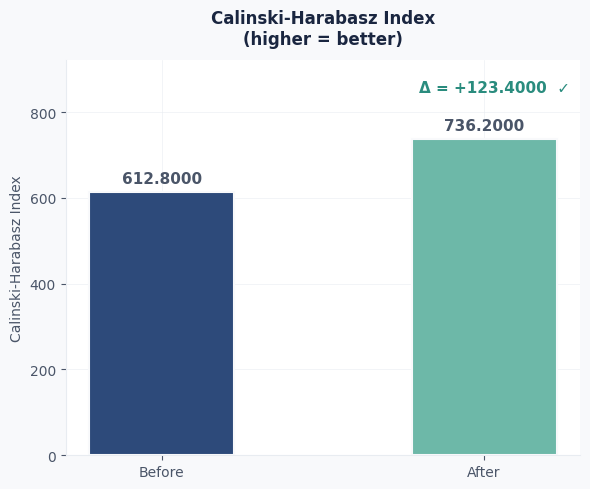

🖼️ Saved: artifacts/lightgbm_smote/image/cluster_intra_comparison.png


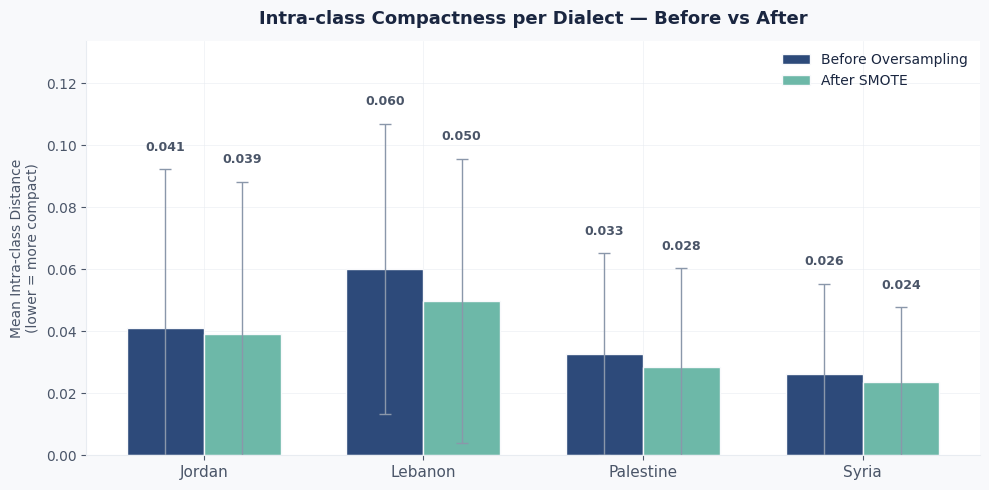


✅ Semua cluster metric plots tersimpan!


In [24]:
# ── Visualisasi perbandingan metrik — MASING-MASING ──────────
metric_plots = [
    ("silhouette",        "Silhouette Score",          True,  "higher = better"),
    ("mean_inter_dist",   "Mean Inter-class Distance", True,  "higher = more separated"),
    ("mean_intra_dist",   "Mean Intra-class Distance", False, "lower = more compact"),
    ("overlap_score",     "Overlap Score",             False, "lower = less overlap"),
    ("davies_bouldin",    "Davies-Bouldin Index",      False, "lower = better"),
    ("calinski_harabasz", "Calinski-Harabasz Index",   True,  "higher = better"),
]

labels = ["Before", "After"]
colors = ["#2D4A7A", "#6DB8A8"]

for key, title, higher_better, note in metric_plots:
    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG_COLOR)
    if 'apply_plot_style' in globals(): apply_plot_style(ax) 
    else: ax.set_facecolor(CARD_COLOR); ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6); ax.set_axisbelow(True); ax.spines[['top', 'right']].set_visible(False)

    vals = [mb[key], ma[key]]
    bars = ax.bar(labels, vals, color=colors, edgecolor=BG_COLOR, linewidth=1.5, width=0.45)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(vals) * 0.02),
                f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color=TEXT_MID)

    # Delta annotation
    delta = vals[1] - vals[0]
    is_improved = (delta > 0) == higher_better
    color_delta = "#2A8C7E" if is_improved else "#A63D2F"
    symbol = "✓" if is_improved else "!"
    
    ax.text(0.98, 0.95, f"Δ = {delta:+.4f}  {symbol}", transform=ax.transAxes, 
            ha='right', va='top', fontsize=11, fontweight='bold', color=color_delta)

    ax.set_title(f"{title}\n({note})", fontsize=12, fontweight='bold', color=TEXT_DARK, pad=12)
    ax.set_ylabel(title, fontsize=10, color=TEXT_MID)

    max_v, min_v = max(vals), min(0, min(vals) * 1.2)
    ax.set_ylim(min_v, max_v * 1.25)

    fig.tight_layout()
    save_and_show(f"cluster_metric_{key}")


# ── Intra per class — before vs after ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG_COLOR)
if 'apply_plot_style' in globals(): apply_plot_style(ax)

classes_list = list(label_names)
x_pos = np.arange(len(classes_list))
w = 0.35

vals_b, stds_b = np.array([mb["intra_per_class"][c]["mean"] for c in classes_list]), np.array([mb["intra_per_class"][c]["std"] for c in classes_list])
vals_a, stds_a = np.array([ma["intra_per_class"][c]["mean"] for c in classes_list]), np.array([ma["intra_per_class"][c]["std"] for c in classes_list])

bars_b = ax.bar(x_pos - w/2, vals_b, width=w, color="#2D4A7A", label="Before Oversampling", 
                edgecolor=BG_COLOR, yerr=stds_b, capsize=4, error_kw=dict(elinewidth=1, ecolor=TEXT_LIGHT))
bars_a = ax.bar(x_pos + w/2, vals_a, width=w, color="#6DB8A8", label="After SMOTE", 
                edgecolor=BG_COLOR, yerr=stds_a, capsize=4, error_kw=dict(elinewidth=1, ecolor=TEXT_LIGHT))

for bar, val, std in zip(list(bars_b) + list(bars_a), np.concatenate([vals_b, vals_a]), np.concatenate([stds_b, stds_a])):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.005, 
            f"{val:.3f}", ha='center', va='bottom', fontsize=9, color=TEXT_MID, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(classes_list, fontsize=11)
ax.set_ylabel("Mean Intra-class Distance\n(lower = more compact)", fontsize=10, color=TEXT_MID)
ax.set_title("Intra-class Compactness per Dialect — Before vs After", fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.legend(frameon=False, fontsize=10)

max_y_val = max(np.max(vals_b + stds_b), np.max(vals_a + stds_a))
ax.set_ylim(0, max_y_val * 1.25)

fig.tight_layout()
save_and_show("cluster_intra_comparison")

print("\n✅ Semua cluster metric plots tersimpan!")

## Modeling

### Class Weights

In [25]:
def class_weights_effective(y, beta=0.999):
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    eff_num = (1 - np.power(beta, counts)) / (1 - beta)
    weights = 1.0 / eff_num
    weights = weights / weights.min()
    return {c: float(w) for c, w in zip(classes, weights)}
 
class_weight_dict = class_weights_effective(y_train, beta=0.999)

### Final Model Training

In [26]:
model = lgb.LGBMClassifier(
    objective="multiclass", num_class=len(label_names),
    n_estimators=10000, learning_rate=0.01,
    max_depth=7, min_child_weight=1e-3,
    subsample=0.75, subsample_freq=1,
    random_state=42, n_jobs=-1, force_col_wise=True, verbose=-1,
    **best_params
)
print("Training model...")
model.fit(
    Xtr_os, ytr_os,
    eval_set=[(Xtr_os, ytr_os), (Xval_sel, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, min_delta=1e-4),
        lgb.log_evaluation(100),
    ]
)
print("Best iteration:", model.best_iteration_)

Training model...
Training until validation scores don't improve for 150 rounds
[100]	training's multi_logloss: 0.489568	valid_1's multi_logloss: 0.482461
[200]	training's multi_logloss: 0.328216	valid_1's multi_logloss: 0.351437
[300]	training's multi_logloss: 0.273674	valid_1's multi_logloss: 0.322826
[400]	training's multi_logloss: 0.242962	valid_1's multi_logloss: 0.31397
[500]	training's multi_logloss: 0.219897	valid_1's multi_logloss: 0.309492
[600]	training's multi_logloss: 0.201917	valid_1's multi_logloss: 0.306554
[700]	training's multi_logloss: 0.186252	valid_1's multi_logloss: 0.304273
[800]	training's multi_logloss: 0.173468	valid_1's multi_logloss: 0.302496
[900]	training's multi_logloss: 0.162191	valid_1's multi_logloss: 0.301255
[1000]	training's multi_logloss: 0.152163	valid_1's multi_logloss: 0.300155
[1100]	training's multi_logloss: 0.143209	valid_1's multi_logloss: 0.29955
[1200]	training's multi_logloss: 0.135079	valid_1's multi_logloss: 0.298991
[1300]	training's m

✅ History learning curve berhasil disimpan ke: artifacts/lightgbm_smote/docs/lightgbm_smote_learning_curve_history.csv
🖼️ Saved: artifacts/lightgbm_smote/image/learning_curve_loss.png


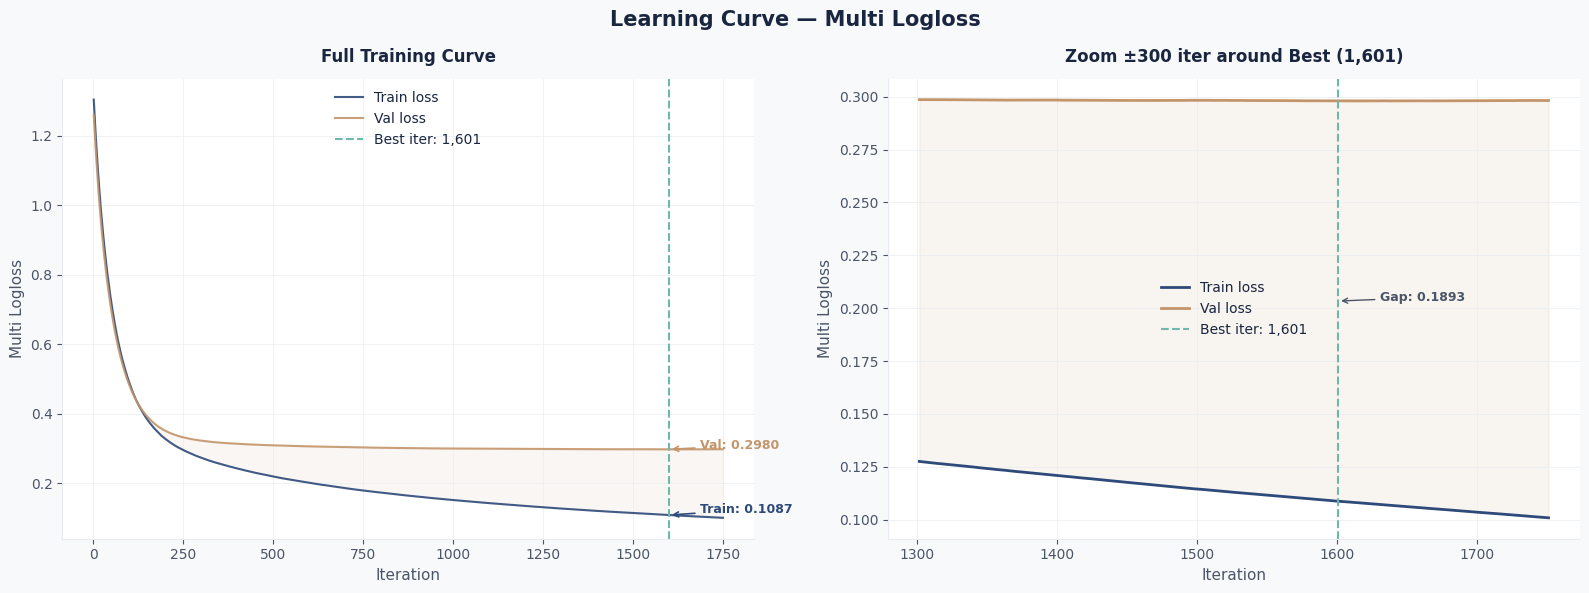

In [27]:
# ── Learning Curve ───────────────────────────────────────────
results  = model.evals_result_
train_loss = results['training']['multi_logloss']
val_loss   = results['valid_1']['multi_logloss']
iterations = range(1, len(train_loss) + 1)
best_iter  = model.best_iteration_

history_df = pd.DataFrame({
    'Iteration': iterations,
    'Train_Multi_Logloss': train_loss,
    'Val_Multi_Logloss': val_loss
})

# Tambahkan penanda (flag) khusus untuk iterasi terbaik
history_df['Is_Best_Iteration'] = history_df['Iteration'] == best_iter

# Simpan ke CSV (menggunakan variabel DOCS_DIR dan KOMPOSISI dari kodemu sebelumnya)
csv_path = os.path.join(DOCS_DIR, f"{KOMPOSISI}_learning_curve_history.csv")
history_df.to_csv(csv_path, index=False)

print(f"✅ History learning curve berhasil disimpan ke: {csv_path}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle("Learning Curve — Multi Logloss",
             fontsize=15, fontweight='bold', color=TEXT_DARK)

# ── Kiri: full curve ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CARD_COLOR)

ax.plot(iterations, train_loss,
        color="#2D4A7A", linewidth=1.5,
        label="Train loss", alpha=0.9)
ax.plot(iterations, val_loss,
        color="#C4956A", linewidth=1.5,
        label="Val loss", alpha=0.9)

# shading gap antara train dan val
ax.fill_between(iterations, train_loss, val_loss,
                alpha=0.08, color="#C4956A")

# best iteration line
ax.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
           linestyle="--", label=f"Best iter: {best_iter:,}")

# annotasi nilai loss di best iter
ax.annotate(
    f"Val: {val_loss[best_iter-1]:.4f}",
    xy=(best_iter, val_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, val_loss[best_iter-1]),
    fontsize=9, color="#C4956A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#C4956A", lw=1.2),
)
ax.annotate(
    f"Train: {train_loss[best_iter-1]:.4f}",
    xy=(best_iter, train_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, train_loss[best_iter-1]*1.05),
    fontsize=9, color="#2D4A7A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#2D4A7A", lw=1.2),
)

ax.set_xlabel("Iteration",       fontsize=11, color=TEXT_MID)
ax.set_ylabel("Multi Logloss",   fontsize=11, color=TEXT_MID)
ax.set_title("Full Training Curve", fontsize=12,
             fontweight='bold', color=TEXT_DARK)
ax.legend(frameon=False, fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.6)
ax.spines[['top','right']].set_visible(False)

# ── Kanan: zoom di sekitar best iteration ────────────────────
ax2 = axes[1]
ax2.set_facecolor(CARD_COLOR)

zoom_start = max(0, best_iter - 300)
zoom_end   = min(len(train_loss), best_iter + 300)
iters_zoom = range(zoom_start + 1, zoom_end + 1)

ax2.plot(iters_zoom, train_loss[zoom_start:zoom_end],
         color="#2D4A7A", linewidth=2, label="Train loss")
ax2.plot(iters_zoom, val_loss[zoom_start:zoom_end],
         color="#C4956A", linewidth=2, label="Val loss")
ax2.fill_between(iters_zoom,
                 train_loss[zoom_start:zoom_end],
                 val_loss[zoom_start:zoom_end],
                 alpha=0.1, color="#C4956A")
ax2.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
            linestyle="--", label=f"Best iter: {best_iter:,}")

# gap label
gap = val_loss[best_iter-1] - train_loss[best_iter-1]
ax2.annotate(
    f"Gap: {gap:.4f}",
    xy=(best_iter, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    xytext=(best_iter + 30, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    fontsize=9, color=TEXT_MID, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=TEXT_MID, lw=1.0),
)

ax2.set_xlabel("Iteration",     fontsize=11, color=TEXT_MID)
ax2.set_ylabel("Multi Logloss", fontsize=11, color=TEXT_MID)
ax2.set_title(f"Zoom ±300 iter around Best ({best_iter:,})",
              fontsize=12, fontweight='bold', color=TEXT_DARK)
ax2.legend(frameon=False, fontsize=10)
ax2.grid(color=GRID_COLOR, linewidth=0.6)
ax2.spines[['top','right']].set_visible(False)

fig.tight_layout()
save_and_show("learning_curve_loss")

🖼️ Saved: artifacts/lightgbm_smote/image/learning_curve_full.png


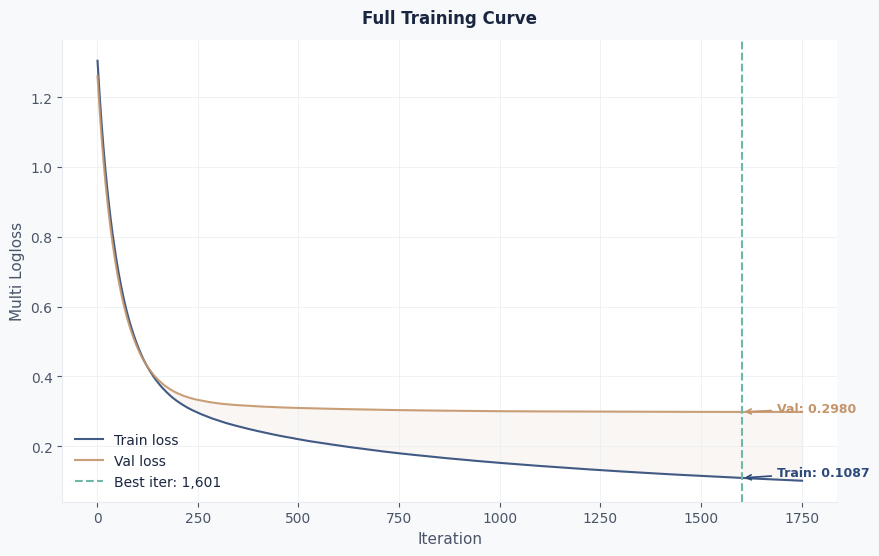

🖼️ Saved: artifacts/lightgbm_smote/image/learning_curve_zoom.png


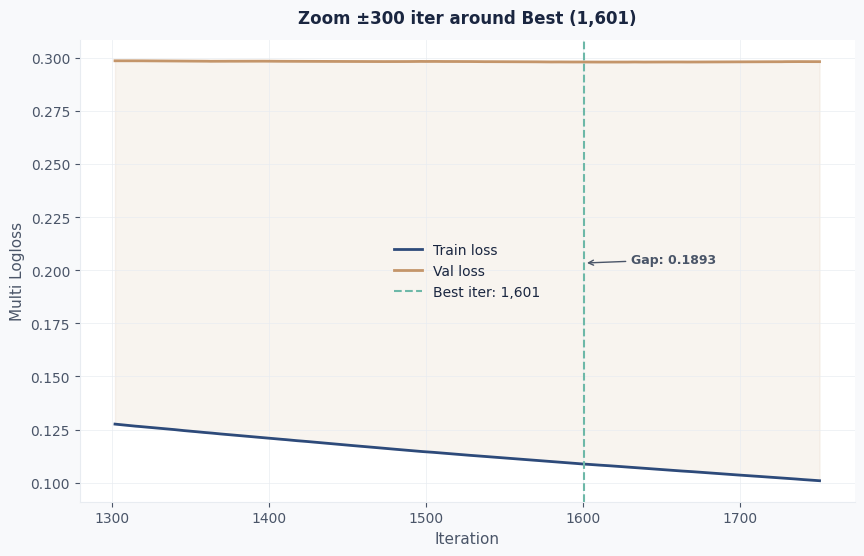


=== LEARNING CURVE SUMMARY ===
Total iterations trained : 1,751
Best iteration           : 1,601
Train loss @ best        : 0.1087
Val   loss @ best        : 0.2980
Gap (val - train)        : 0.1893
Early stop saved iters   : 150


In [28]:
# ── Learning Curve ───────────────────────────────────────────
plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

plt.plot(iterations, train_loss,
         color="#2D4A7A", linewidth=1.5,
         label="Train loss", alpha=0.9)
plt.plot(iterations, val_loss,
         color="#C4956A", linewidth=1.5,
         label="Val loss", alpha=0.9)

plt.fill_between(iterations, train_loss, val_loss,
                 alpha=0.08, color="#C4956A")

plt.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
            linestyle="--", label=f"Best iter: {best_iter:,}")

# annotasi
plt.annotate(
    f"Val: {val_loss[best_iter-1]:.4f}",
    xy=(best_iter, val_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, val_loss[best_iter-1]),
    fontsize=9, color="#C4956A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#C4956A", lw=1.2),
)
plt.annotate(
    f"Train: {train_loss[best_iter-1]:.4f}",
    xy=(best_iter, train_loss[best_iter-1]),
    xytext=(best_iter + len(iterations)*0.05, train_loss[best_iter-1]*1.05),
    fontsize=9, color="#2D4A7A", fontweight='bold',
    arrowprops=dict(arrowstyle='->', color="#2D4A7A", lw=1.2),
)

plt.xlabel("Iteration", fontsize=11, color=TEXT_MID)
plt.ylabel("Multi Logloss", fontsize=11, color=TEXT_MID)
plt.title("Full Training Curve", fontsize=12,
          fontweight='bold', color=TEXT_DARK)

plt.legend(frameon=False)
plt.grid(color=GRID_COLOR, linewidth=0.6)
ax.spines[['top','right']].set_visible(False)

save_and_show("learning_curve_full")

plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

zoom_start = max(0, best_iter - 300)
zoom_end   = min(len(train_loss), best_iter + 300)
iters_zoom = range(zoom_start + 1, zoom_end + 1)

plt.plot(iters_zoom, train_loss[zoom_start:zoom_end],
         color="#2D4A7A", linewidth=2, label="Train loss")
plt.plot(iters_zoom, val_loss[zoom_start:zoom_end],
         color="#C4956A", linewidth=2, label="Val loss")

plt.fill_between(iters_zoom,
                 train_loss[zoom_start:zoom_end],
                 val_loss[zoom_start:zoom_end],
                 alpha=0.1, color="#C4956A")

plt.axvline(best_iter, color="#6DB8A8", linewidth=1.5,
            linestyle="--", label=f"Best iter: {best_iter:,}")

# gap annotation
gap = val_loss[best_iter-1] - train_loss[best_iter-1]
plt.annotate(
    f"Gap: {gap:.4f}",
    xy=(best_iter, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    xytext=(best_iter + 30, (val_loss[best_iter-1] + train_loss[best_iter-1]) / 2),
    fontsize=9, color=TEXT_MID, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=TEXT_MID, lw=1.0),
)

plt.xlabel("Iteration", fontsize=11, color=TEXT_MID)
plt.ylabel("Multi Logloss", fontsize=11, color=TEXT_MID)
plt.title(f"Zoom ±300 iter around Best ({best_iter:,})",
          fontsize=12, fontweight='bold', color=TEXT_DARK)

plt.legend(frameon=False)
plt.grid(color=GRID_COLOR, linewidth=0.6)
ax.spines[['top','right']].set_visible(False)

save_and_show("learning_curve_zoom")

# ── Summary stats ────────────────────────────────────────────
print(f"\n=== LEARNING CURVE SUMMARY ===")
print(f"Total iterations trained : {len(train_loss):,}")
print(f"Best iteration           : {best_iter:,}")
print(f"Train loss @ best        : {train_loss[best_iter-1]:.4f}")
print(f"Val   loss @ best        : {val_loss[best_iter-1]:.4f}")
print(f"Gap (val - train)        : {val_loss[best_iter-1] - train_loss[best_iter-1]:.4f}")
print(f"Early stop saved iters   : {len(train_loss) - best_iter:,}")

## Save Artifacts

In [29]:
print("💾 Menyimpan artifacts modeling...")

joblib.dump(model, os.path.join(MODEL_DIR, f"model_{KOMPOSISI}.pkl"))
joblib.dump(feat, os.path.join(SAVE_DIR, "shami_feature_extractor.pkl"))
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

print("✅ Artifacts modeling berhasil disimpan!")

💾 Menyimpan artifacts modeling...
✅ Artifacts modeling berhasil disimpan!


## Evaluation & Analysis

### Evaluation Report

In [30]:
def evaluate_split(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Macro F1 :", f1_score(y_true, y_pred, average="macro"))
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
 
for split_name, X_sp, y_sp in [
    ("TRAIN", Xtr_os,  ytr_os),
    ("VAL",   Xval_sel, y_val),
    ("TEST",  Xte_sel,  y_test),
]:
    evaluate_split(split_name, y_sp,
                   model.predict(X_sp, num_iteration=model.best_iteration_))
 
cm    = confusion_matrix(y_test, model.predict(Xte_sel, num_iteration=model.best_iteration_))
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
print("\nConfusion Matrix:\n", cm_df)


===== TRAIN =====
Accuracy : 0.9716192452938972
Macro F1 : 0.9674073720404275
              precision    recall  f1-score   support

      Jordan     0.9633    0.9283    0.9455      7899
     Lebanon     0.9696    0.9754    0.9725     19423
   Palestine     0.9717    0.9745    0.9731     19401
       Syria     0.9760    0.9810    0.9785     22655

    accuracy                         0.9716     69378
   macro avg     0.9702    0.9648    0.9674     69378
weighted avg     0.9716    0.9716    0.9716     69378


===== VAL =====
Accuracy : 0.8969507899768542
Macro F1 : 0.8524351071606444
              precision    recall  f1-score   support

      Jordan     0.8251    0.7303    0.7748      1053
     Lebanon     0.8451    0.8534    0.8493      1624
   Palestine     0.8225    0.8509    0.8365      1596
       Syria     0.9450    0.9534    0.9492      5664

    accuracy                         0.8970      9937
   macro avg     0.8595    0.8470    0.8524      9937
weighted avg     0.8963    0.

### Confusion matrix heatmap

🖼️ Saved: artifacts/lightgbm_smote/image/confusion_matrix.png


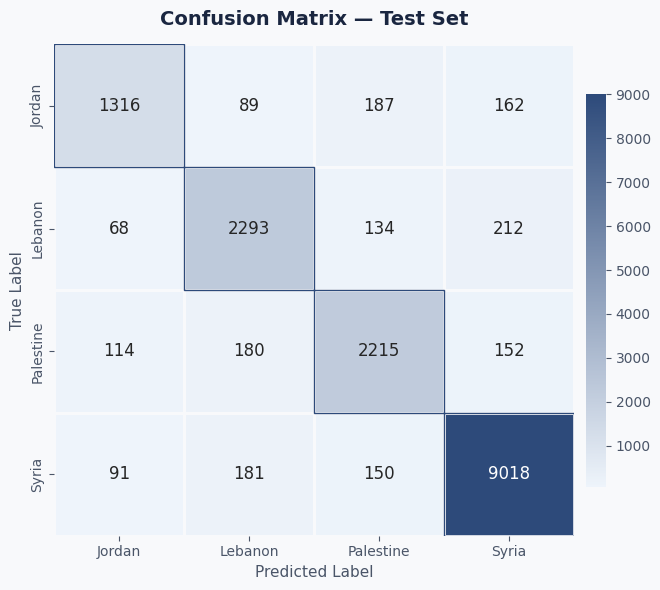


=== SUMMARY ===
Train F1 : 0.9674
Val F1   : 0.8524
Test F1  : 0.8518
Gap T-V  : 0.1150  ⚠ overfit
Gap V-Te : 0.0006  ✓ generalize baik


In [31]:
# ── 2. Confusion Matrix ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)

cmap = LinearSegmentedColormap.from_list(
    "custom_blue", ["#EEF4FB", "#2D4A7A"], N=256)

sns.heatmap(
    cm_df, annot=True, fmt='d', cmap=cmap,
    linewidths=2, linecolor=BG_COLOR,
    annot_kws={"size": 12},
    ax=ax, cbar_kws={"shrink": 0.8, "pad": 0.02}
)

ax.grid(False)

# Highlight diagonal
for i in range(len(cm_df)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                 fill=False, edgecolor="#2D4A7A", lw=1))

ax.set_title("Confusion Matrix — Test Set",
             fontsize=14, fontweight='bold', color=TEXT_DARK, pad=14)
ax.set_ylabel("True Label",     fontsize=11, color=TEXT_MID)
ax.set_xlabel("Predicted Label", fontsize=11, color=TEXT_MID)
ax.tick_params(axis='both', labelsize=10)
ax.figure.facecolor = BG_COLOR

fig.tight_layout()
save_and_show("confusion_matrix")


f1_tr  = f1_score(ytr_os, model.predict(Xtr_os,  num_iteration=model.best_iteration_), average="macro")
f1_val = f1_score(y_val,   model.predict(Xval_sel, num_iteration=model.best_iteration_), average="macro")
f1_te  = f1_score(y_test,  model.predict(Xte_sel,  num_iteration=model.best_iteration_), average="macro")
print(f"\n=== SUMMARY ===")
print(f"Train F1 : {f1_tr:.4f}")
print(f"Val F1   : {f1_val:.4f}")
print(f"Test F1  : {f1_te:.4f}")
print(f"Gap T-V  : {f1_tr - f1_val:.4f}  {'⚠ overfit' if f1_tr - f1_val > 0.10 else '✓ ok'}")
print(f"Gap V-Te : {abs(f1_val - f1_te):.4f}  {'✓ generalize baik' if abs(f1_val - f1_te) < 0.01 else '△ cek'}")
 

### Feature Importance per Block

🖼️ Saved: artifacts/lightgbm_smote/image/feature_importance_total.png


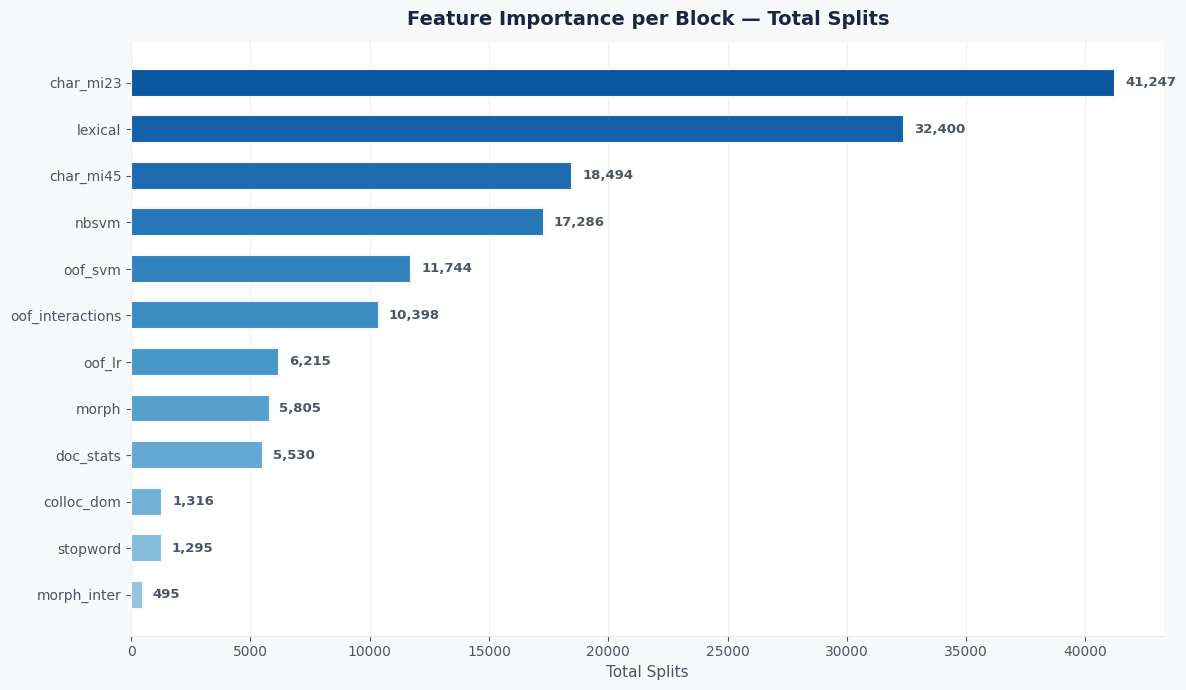

   Feature_Block  Total_Importance  Average_Importance_per_Col  Cols
       char_mi23             41247                   82.494000   500
         lexical             32400                   13.388430  2420
       char_mi45             18494                    6.978868  2650
           nbsvm             17286                 4321.500000     4
         oof_svm             11744                 1468.000000     8
oof_interactions             10398                 1039.800000    10
          oof_lr              6215                  776.875000     8
           morph              5805                  223.269231    26
       doc_stats              5530                  790.000000     7
      colloc_dom              1316                 1316.000000     1
        stopword              1295                  647.500000     2
     morph_inter               495                   61.875000     8


In [32]:
importances  = model.feature_importances_
block_slices_imp = build_block_slices(feat.block_sizes)
 
block_importance = {}
for name, (s, e) in block_slices_imp.items():
    if name in drop_list or s >= len(importances):
        continue
    end_idx  = min(e, len(importances))
    blk_imp  = importances[s:end_idx]
    if len(blk_imp) == 0:
        continue
    block_importance[name] = {
        'Total_Importance'          : blk_imp.sum(),
        'Average_Importance_per_Col': blk_imp.mean(),
        'Cols'                      : len(blk_imp),
    }
 
df_imp = (
    pd.DataFrame.from_dict(block_importance, orient='index')
      .reset_index().rename(columns={'index': 'Feature_Block'})
      .sort_values('Total_Importance', ascending=False)
)
 
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

n      = len(df_imp)
colors = plt.cm.Blues(np.linspace(0.4, 0.85, n))[::-1]

bars = ax.barh(df_imp['Feature_Block'], df_imp['Total_Importance'],
               color=colors, edgecolor=BG_COLOR, linewidth=1.5, height=0.6)

# Value labels
for bar, val in zip(bars, df_imp['Total_Importance']):
    ax.text(bar.get_width() + df_imp['Total_Importance'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va='center', ha='left',
            fontsize=9.5, color=TEXT_MID, fontweight='bold')

ax.set_xlabel("Total Splits", fontsize=11, color=TEXT_MID)
ax.set_ylabel("")
ax.set_title("Feature Importance per Block — Total Splits",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)

ax.invert_yaxis()

fig.tight_layout()
save_and_show("feature_importance_total")

print(df_imp.to_string(index=False))

### Average importance per column

🖼️ Saved: artifacts/lightgbm_smote/image/feature_importance_avg.png


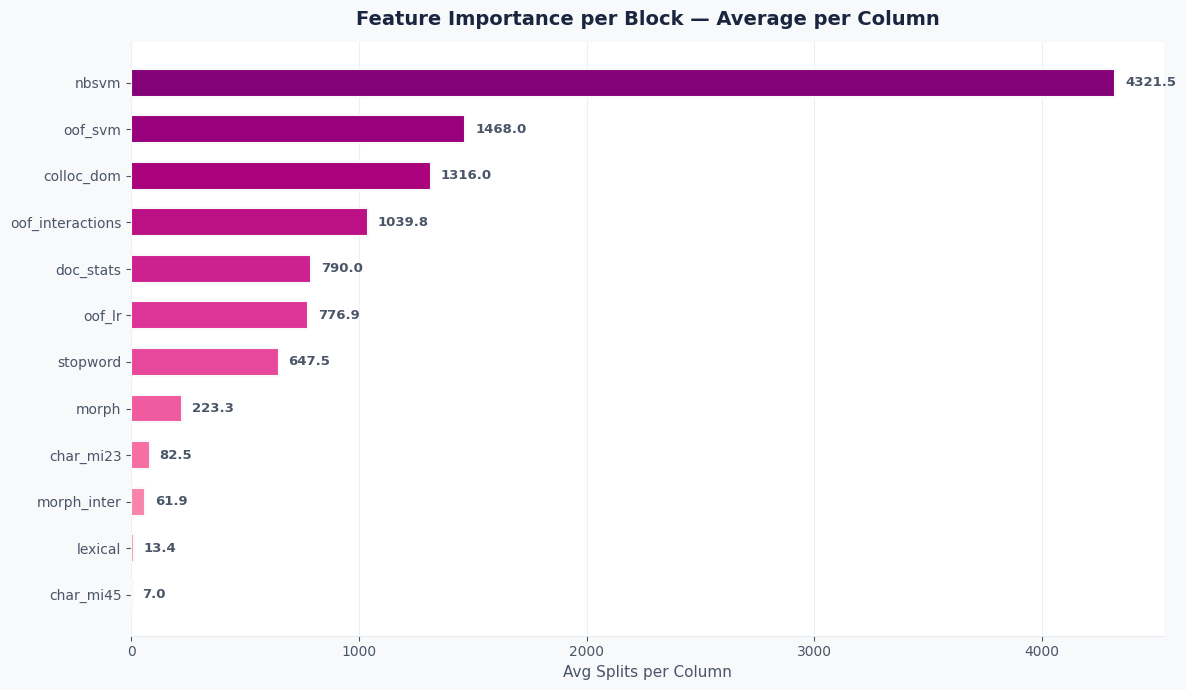

In [33]:
df_imp_avg = df_imp.sort_values('Average_Importance_per_Col', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

n      = len(df_imp_avg)
colors = plt.cm.RdPu(np.linspace(0.35, 0.85, n))[::-1]

bars = ax.barh(df_imp_avg['Feature_Block'],
               df_imp_avg['Average_Importance_per_Col'],
               color=colors, edgecolor=BG_COLOR, linewidth=1.5, height=0.6)

for bar, val in zip(bars, df_imp_avg['Average_Importance_per_Col']):
    ax.text(bar.get_width() + df_imp_avg['Average_Importance_per_Col'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va='center', ha='left',
            fontsize=9.5, color=TEXT_MID, fontweight='bold')

ax.set_xlabel("Avg Splits per Column", fontsize=11, color=TEXT_MID)
ax.set_ylabel("")
ax.set_title("Feature Importance per Block — Average per Column",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)

ax.invert_yaxis()

fig.tight_layout()
save_and_show("feature_importance_avg")

### Clustering Analysis

In [34]:
from sklearn.neighbors import NearestNeighbors

def synthetic_quality_analysis(X_orig, X_synth, y_orig, y_synth,
                                 label_names, method_name):
    """
    Bandingkan distribusi jarak NN antara:
    - sampel asli ke tetangga aslinya
    - sampel sintetis ke tetangga aslinya
    Semakin mirip distribusinya, semakin realistis synthetic samples.
    """
    results = {}
    classes = np.unique(y_orig)

    for c in classes:
        cls_name  = label_names[c]
        idx_orig  = np.where(y_orig  == c)[0]
        idx_synth = np.where(y_synth == c)[0]

        if len(idx_synth) == 0:
            continue

        X_c_orig  = X_orig[idx_orig]
        X_c_synth = X_synth[idx_synth]

        if issparse(X_c_orig):
            X_c_orig  = X_c_orig.toarray()
            X_c_synth = X_c_synth.toarray()

        # fit NN di sampel asli
        k   = min(5, len(idx_orig) - 1)
        nn  = NearestNeighbors(n_neighbors=k+1, metric='cosine',
                               algorithm='brute')
        nn.fit(X_c_orig)

        # jarak sampel asli ke NN-nya (distribusi referensi)
        dist_orig, _  = nn.kneighbors(X_c_orig)
        dist_orig     = dist_orig[:, 1:].mean(axis=1)  # buang self

        # jarak sampel sintetis ke NN asli
        # subsample sintetis kalau terlalu banyak
        n_syn = min(len(idx_synth), 2000)
        rng   = np.random.default_rng(42)
        s_idx = rng.choice(len(idx_synth), n_syn, replace=False)
        dist_synth, _ = nn.kneighbors(X_c_synth[s_idx])
        dist_synth    = dist_synth[:, 0:].mean(axis=1)

        results[cls_name] = {
            "orig_mean"  : float(np.mean(dist_orig)),
            "orig_std"   : float(np.std(dist_orig)),
            "synth_mean" : float(np.mean(dist_synth)),
            "synth_std"  : float(np.std(dist_synth)),
            "ratio"      : float(np.mean(dist_synth) / (np.mean(dist_orig) + 1e-9)),
            # ratio mendekati 1.0 = sampel sintetis "sebidang" dengan asli
            # ratio >> 1.0 = sampel sintetis terlalu jauh (noise)
            # ratio << 1.0 = sampel sintetis terlalu dekat (duplikasi)
        }

    return results


def inter_class_intrusion(X_os, y_os, y_orig, label_names, method_name):
    """
    Hitung berapa persen sampel sintetis kelas A yang
    lebih dekat ke centroid kelas lain (intrusi).
    Semakin rendah = semakin bersih.
    """
    # identifikasi mana yang sintetis
    n_orig   = len(y_orig)
    y_synth  = y_os[n_orig:]
    X_synth  = X_os[n_orig:]
    classes  = np.unique(y_orig)

    if issparse(X_os):
        X_arr = X_os.toarray()
    else:
        X_arr = np.asarray(X_os)

    Xn = normalize(X_arr, norm="l2")

    # centroid per kelas dari data ASLI saja
    centroids = {}
    for c in classes:
        idx = np.where(y_orig == c)[0]
        mu  = Xn[idx].mean(axis=0)
        centroids[c] = mu / (np.linalg.norm(mu) + 1e-9)

    if issparse(X_synth):
        X_synth_arr = X_synth.toarray()
    else:
        X_synth_arr = np.asarray(X_synth)

    Xsn = normalize(X_synth_arr, norm="l2")

    intrusion_per_class = {}
    for c in classes:
        idx_c = np.where(y_synth == c)[0]
        if len(idx_c) == 0:
            continue
        Xsc = Xsn[idx_c]

        # cosine similarity ke semua centroid
        sims = np.array([Xsc @ centroids[cc] for cc in classes]).T
        pred = np.argmax(sims, axis=1)  # kelas terdekat

        correct  = np.sum(pred == list(classes).index(c))
        intruded = len(idx_c) - correct
        intrusion_per_class[label_names[c]] = {
            "n_synth"       : len(idx_c),
            "n_intruded"    : int(intruded),
            "intrusion_rate": round(intruded / len(idx_c), 4),
        }

    return intrusion_per_class

def decision_boundary_analysis(model_before, model_after,
                                 Xte_sel, y_test, label_names):
    """
    Bandingkan:
    - Confidence shift: apakah model lebih confident untuk minority class?
    - Boundary sharpness: apakah margin keputusan meningkat?
    - Per-class improvement: kelas mana yang paling diuntungkan?
    """
    proba_before = model_before.predict_proba(
        Xte_sel, num_iteration=model_before.best_iteration_)
    proba_after  = model_after.predict_proba(
        Xte_sel, num_iteration=model_after.best_iteration_)

    results = {}
    for i, cls_name in enumerate(label_names):
        mask = y_test == i

        # confidence untuk kelas ini
        conf_b = proba_before[mask, i]
        conf_a = proba_after[mask, i]

        # margin = prob kelas benar - prob kelas terkuat lainnya
        margin_b = (np.sort(proba_before[mask], axis=1)[:, -1]
                  - np.sort(proba_before[mask], axis=1)[:, -2])
        margin_a = (np.sort(proba_after[mask],  axis=1)[:, -1]
                  - np.sort(proba_after[mask],  axis=1)[:, -2])

        # entropy (uncertainty)
        entropy_b = -(proba_before[mask] * np.log(proba_before[mask] + 1e-9)).sum(axis=1)
        entropy_a = -(proba_after[mask]  * np.log(proba_after[mask]  + 1e-9)).sum(axis=1)

        results[cls_name] = {
            "confidence_before"  : round(float(conf_b.mean()), 4),
            "confidence_after"   : round(float(conf_a.mean()), 4),
            "confidence_delta"   : round(float(conf_a.mean() - conf_b.mean()), 4),
            "margin_before"      : round(float(margin_b.mean()), 4),
            "margin_after"       : round(float(margin_a.mean()), 4),
            "margin_delta"       : round(float(margin_a.mean() - margin_b.mean()), 4),
            "entropy_before"     : round(float(entropy_b.mean()), 4),
            "entropy_after"      : round(float(entropy_a.mean()), 4),
            "entropy_delta"      : round(float(entropy_a.mean() - entropy_b.mean()), 4),
        }

    return results

In [35]:
n_orig = len(y_train)
X_synth = Xtr_os[n_orig:]
y_synth = ytr_os[n_orig:]

print("\n" + "=".center(60, "="))
print(" 1. SYNTHETIC QUALITY ANALYSIS ".center(60, "="))
print("=".center(60, "="))
# Mengukur apakah jarak sampel buatan ke sampel asli itu natural atau tidak
quality_res = synthetic_quality_analysis(
    X_orig=Xtr_sel, 
    X_synth=X_synth, 
    y_orig=y_train, 
    y_synth=y_synth,
    label_names=label_names, 
    method_name="SMOTE"
)

for cls, res in quality_res.items():
    print(f"💠 Dialect: {cls}")
    print(f"   - Jarak Asli (Referense) : {res['orig_mean']:.4f} ± {res['orig_std']:.4f}")
    print(f"   - Jarak Sintetis         : {res['synth_mean']:.4f} ± {res['synth_std']:.4f}")
    print(f"   - Quality Ratio          : {res['ratio']:.4f} " 
          f"{'(✅ Sangat Realistis)' if 0.8 <= res['ratio'] <= 1.2 else '(⚠️ Agak Noise/Duplikat)'}\n")


print("=".center(60, "="))
print(" 2. INTER-CLASS INTRUSION ANALYSIS ".center(60, "="))
print("=".center(60, "="))
# Mengukur apakah SMOTE secara tidak sengaja membuat data yang nyebrang ke wilayah negara lain
intrusion_res = inter_class_intrusion(
    X_os=Xtr_os, 
    y_os=ytr_os, 
    y_orig=y_train, 
    label_names=label_names, 
    method_name="SMOTE"
)

for cls, res in intrusion_res.items():
    print(f"💠 Dialect: {cls}")
    print(f"   - Total Data Sintetis : {res['n_synth']:,} samples")
    print(f"   - Nyasar (Intruded)   : {res['n_intruded']:,} samples")
    print(f"   - Intrusion Rate      : {res['intrusion_rate'] * 100:.2f}% "
          f"{'(✅ Bersih)' if res['intrusion_rate'] < 0.1 else '(⚠️ Hati-hati Overlapping)'}\n")


print("=".center(60, "="))
print(" 3. DECISION BOUNDARY ANALYSIS ".center(60, "="))
print("=".center(60, "="))
# Menganalisis apakah model baru lebih "Pede" dan batas tebakannya lebih tegas di Test Set
# Asumsi: 
# 'model' = Model Baseline yang diload di awal (joblib.load)
# 'm' = Model LGBM yang baru di-training pakai Xtr_os di script SMOTE sebelumnya
model_original = joblib.load(os.path.join("artifacts/lightgbm_original/model", "model_lightgbm_original.pkl"))

try:
    boundary_res = decision_boundary_analysis(
        model_before=model_original, # Ini yang benar
        model_after=model,           # 'model' adalah LGBM final setelah SMOTE
        Xte_sel=Xte_sel, 
        y_test=y_test, 
        label_names=label_names
    )

    for cls, res in boundary_res.items():
        print(f"💠 Dialect: {cls}")
        # Confidence: Tingkat kepastian model nebak (Makin tinggi makin bagus)
        print(f"   - Confidence : {res['confidence_before']:.4f} → {res['confidence_after']:.4f} "
              f"(Δ {res['confidence_delta']:+.4f})")
        # Margin: Jarak probabilitas tebakan #1 dengan #2 (Makin tinggi makin bagus)
        print(f"   - Margin     : {res['margin_before']:.4f} → {res['margin_after']:.4f} "
              f"(Δ {res['margin_delta']:+.4f})")
        # Entropy: Kebingungan model (Makin kecil makin bagus)
        print(f"   - Entropy    : {res['entropy_before']:.4f} → {res['entropy_after']:.4f} "
              f"(Δ {res['entropy_delta']:+.4f})\n")
except NameError:
    print("⚠️  Gagal menjalankan Decision Boundary Analysis karena variabel model ('model' atau 'm') belum didefinisikan/dijalankan.")


============== 1. SYNTHETIC QUALITY ANALYSIS ===============
💠 Dialect: Jordan
   - Jarak Asli (Referense) : 0.0285 ± 0.0341
   - Jarak Sintetis         : 0.0166 ± 0.0200
   - Quality Ratio          : 0.5812 (⚠️ Agak Noise/Duplikat)

💠 Dialect: Lebanon
   - Jarak Asli (Referense) : 0.0345 ± 0.0262
   - Jarak Sintetis         : 0.0204 ± 0.0151
   - Quality Ratio          : 0.5930 (⚠️ Agak Noise/Duplikat)

💠 Dialect: Palestine
   - Jarak Asli (Referense) : 0.0238 ± 0.0241
   - Jarak Sintetis         : 0.0144 ± 0.0146
   - Quality Ratio          : 0.6049 (⚠️ Agak Noise/Duplikat)

============ 2. INTER-CLASS INTRUSION ANALYSIS =============
💠 Dialect: Jordan
   - Total Data Sintetis : 3,689 samples
   - Nyasar (Intruded)   : 610 samples
   - Intrusion Rate      : 16.54% (⚠️ Hati-hati Overlapping)

💠 Dialect: Lebanon
   - Total Data Sintetis : 12,925 samples
   - Nyasar (Intruded)   : 2,849 samples
   - Intrusion Rate      : 22.04% (⚠️ Hati-hati Overlapping)

💠 Dialect: Palestine
   - Tota

### Error Analysis

In [36]:
print("\nGenerating Error Analysis...")
test_proba   = model.predict_proba(Xte_sel, num_iteration=model.best_iteration_)
y_pred_final = model.predict(Xte_sel, num_iteration=model.best_iteration_)
label_list   = list(label_names)
idx_jo = label_list.index("Jordan")
idx_le = label_list.index("Lebanon")
idx_pa = label_list.index("Palestine")
idx_sy = label_list.index("Syria")
 
df_export = pd.DataFrame({
    "text"          : X_test["text"].values,
    "clean_word"    : X_test["clean_word"].values,
    "true_label"    : [label_names[i] for i in y_test],
    "pred_label"    : [label_names[i] for i in y_pred_final],
    "correct"       : (y_test == y_pred_final),
    "confidence"    : np.max(test_proba, axis=1).round(4),
    "conf_jordan"   : test_proba[:, idx_jo].round(4),
    "conf_lebanon"  : test_proba[:, idx_le].round(4),
    "conf_palestine": test_proba[:, idx_pa].round(4),
    "conf_syria"    : test_proba[:, idx_sy].round(4),
    "text_len"      : X_test["text"].str.len().values,
    "n_words"       : X_test["text"].str.split().str.len().values,
    # Fitur tambahan untuk analisis tesis
    "entropy"       : (-test_proba * np.log(test_proba + 1e-9)).sum(axis=1).round(4),
    "margin"        : (np.sort(test_proba, axis=1)[:, -1]
                       - np.sort(test_proba, axis=1)[:, -2]).round(4),
})
 
def categorize(row):
    if row["correct"]:           return "correct"
    if row["n_words"] <= 4:      return "too_short_<=4w"
    if row["text_len"] < 30:     return "too_short_<30c"
    if row["confidence"] > 0.85: return "high_conf_wrong"
    if row["confidence"] < 0.45: return "low_conf_ambiguous"
    return "medium_conf_wrong"
 
df_export["error_category"] = df_export.apply(categorize, axis=1)
df_export.to_csv(os.path.join(DOCS_DIR, f"{KOMPOSISI}_error_analysis_full.csv"),
                 index=False, encoding="utf-8-sig")
print(f"Saved: {KOMPOSISI}_error_analysis_full.csv ({len(df_export)} rows)")
 
df_errors = (
    df_export[~df_export["correct"]]
    .sort_values(["true_label", "pred_label", "confidence"],
                 ascending=[True, True, False])
)
df_errors.to_csv(os.path.join(DOCS_DIR, f"{KOMPOSISI}_error_analysis_errors_only.csv"),
                 index=False, encoding="utf-8-sig")
print(f"Saved: {KOMPOSISI}_error_analysis_errors_only.csv ({len(df_errors)} rows)")
 
summary = (
    df_errors.groupby(["true_label", "pred_label", "error_category"])
             .size().reset_index(name="count")
             .sort_values("count", ascending=False)
)
print("\n=== RINGKASAN ERROR ===")
print(summary.to_string(index=False))
print("\n=== DISTRIBUSI KATEGORI ===")
print(df_errors["error_category"].value_counts().to_string())


Generating Error Analysis...
Saved: lightgbm_smote_error_analysis_full.csv (16562 rows)
Saved: lightgbm_smote_error_analysis_errors_only.csv (1720 rows)

=== RINGKASAN ERROR ===
true_label pred_label     error_category  count
    Jordan  Palestine  medium_conf_wrong     81
   Lebanon      Syria  medium_conf_wrong     74
 Palestine      Syria  medium_conf_wrong     73
    Jordan      Syria  medium_conf_wrong     68
     Syria    Lebanon  medium_conf_wrong     66
   Lebanon  Palestine  medium_conf_wrong     64
     Syria  Palestine  medium_conf_wrong     63
 Palestine     Jordan  medium_conf_wrong     54
     Syria     Jordan  medium_conf_wrong     52
 Palestine    Lebanon  medium_conf_wrong     52
     Syria    Lebanon     too_short_<=4w     47
   Lebanon      Syria     too_short_<=4w     44
    Jordan  Palestine    high_conf_wrong     44
 Palestine    Lebanon     too_short_<=4w     42
     Syria    Lebanon     too_short_<30c     41
   Lebanon      Syria    high_conf_wrong     40
 Pale

🖼️ Saved: artifacts/lightgbm_smote/image/confidence_distribution.png


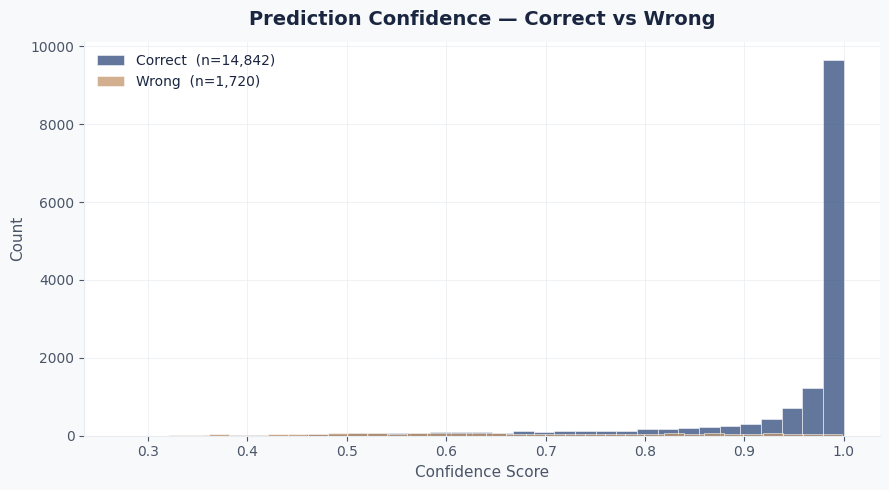

🖼️ Saved: artifacts/lightgbm_smote/image/entropy_per_class.png


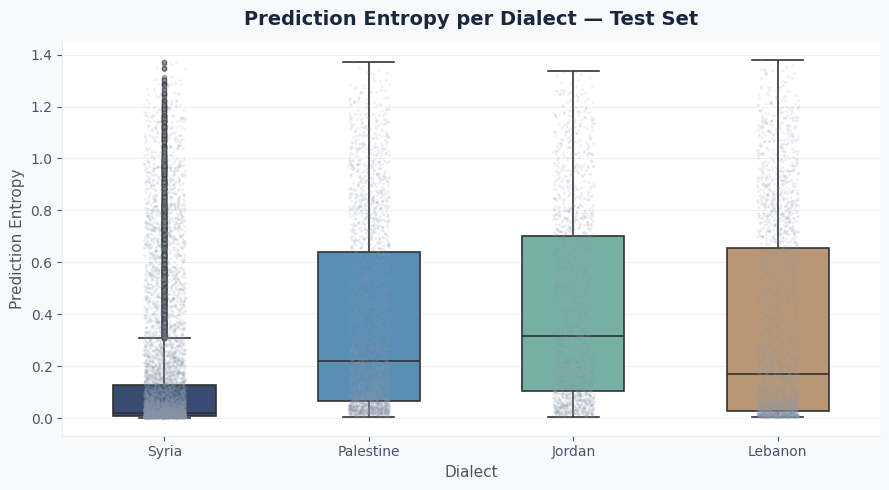

🖼️ Saved: artifacts/lightgbm_smote/image/margin_analysis.png


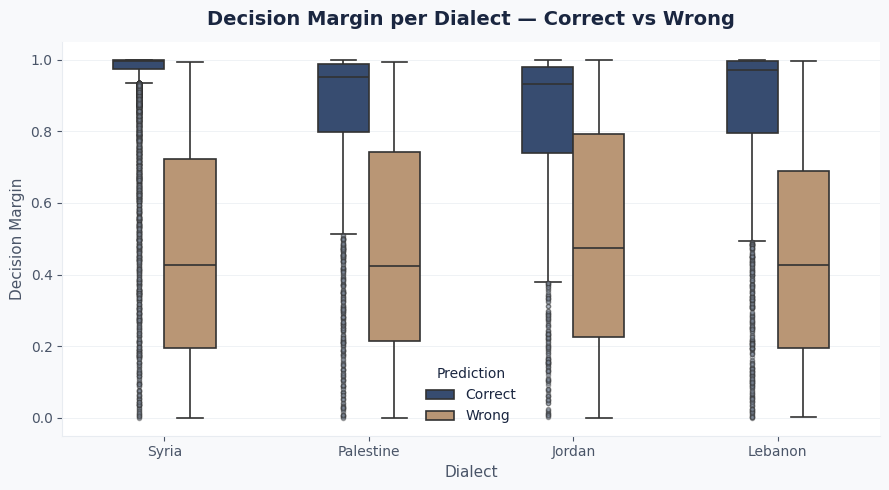

In [37]:
# ── Confidence Distribution ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

for correct, color, label in [
    (True,  "#2D4A7A", "Correct"),
    (False, "#C4956A", "Wrong"),
]:
    subset = df_export[df_export["correct"] == correct]["confidence"]
    ax.hist(subset, bins=35, alpha=0.75, color=color,
            label=f"{label}  (n={len(subset):,})",
            edgecolor="white", linewidth=0.5)

ax.set_xlabel("Confidence Score", fontsize=11, color=TEXT_MID)
ax.set_ylabel("Count",            fontsize=11, color=TEXT_MID)
ax.set_title("Prediction Confidence — Correct vs Wrong",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.grid(True, color=GRID_COLOR)
ax.set_axisbelow(True)

fig.tight_layout()
save_and_show("confidence_distribution")


# ── Entropy per Class ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

sns.boxplot(
    x="true_label", y="entropy", data=df_export,
    palette=PALETTE, width=0.5, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=TEXT_LIGHT,
                    markersize=3, alpha=0.4, linestyle='none'),
    ax=ax
)
sns.stripplot(
    x="true_label", y="entropy", data=df_export,
    color=TEXT_LIGHT, alpha=0.15, size=2, jitter=True, ax=ax
)

ax.set_xlabel("Dialect", fontsize=11, color=TEXT_MID)
ax.set_ylabel("Prediction Entropy", fontsize=11, color=TEXT_MID)
ax.set_title("Prediction Entropy per Dialect — Test Set",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.yaxis.grid(True, color=GRID_COLOR)
ax.set_axisbelow(True)

fig.tight_layout()
save_and_show("entropy_per_class")


# ── Margin Analysis ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)

sns.boxplot(
    x="true_label", y="margin", hue="correct",
    data=df_export,
    palette={True: "#2D4A7A", False: "#C4956A"},  # ← boolean, bukan string
    hue_order=[True, False],
    width=0.5, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=TEXT_LIGHT,
                    markersize=3, alpha=0.4, linestyle='none'),
    ax=ax
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Correct", "Wrong"],
          frameon=False, fontsize=10, title="Prediction")

ax.set_xlabel("Dialect",         fontsize=11, color=TEXT_MID)
ax.set_ylabel("Decision Margin", fontsize=11, color=TEXT_MID)
ax.set_title("Decision Margin per Dialect — Correct vs Wrong",
             fontsize=14, fontweight='bold', color=TEXT_DARK)
ax.yaxis.grid(True, color=GRID_COLOR)
ax.set_axisbelow(True)

fig.tight_layout()
save_and_show("margin_analysis")

### Lexical Exclusivity Analysis (Jordan, Palestine, Syria/Lebanon)

In [38]:
def exclusivity_analysis(df_src, df_all, src_label,
                         top_n=40, min_freq=10, ratio_thresh=4.0):
    """Token yang paling eksklusif di src_label vs semua negara lain."""
    df_others = df_all[df_all['true_label'] != src_label]
    src_tok, oth_tok = Counter(), Counter()
    for t in df_src['clean_word'].dropna():    src_tok.update(str(t).split())
    for t in df_others['clean_word'].dropna(): oth_tok.update(str(t).split())
    n_src, n_oth = len(df_src), len(df_others)
    results = []
    for tok, cnt_s in src_tok.most_common(500):
        if cnt_s < min_freq or len(tok) < 2: continue
        cnt_o = oth_tok.get(tok, 0)
        ratio = (cnt_s / n_src) / ((cnt_o / n_oth) + 1e-6)
        if ratio > ratio_thresh:
            results.append((tok, cnt_s, cnt_o, ratio))
    results.sort(key=lambda x: -x[3])
    print(f"\n=== TOKEN EKSKLUSIF {src_label.upper()} (vs semua) ===")
    print(f"{'Token':15} | {'Freq':8} | {'Freq Lain':10} | {'Rasio':8}")
    print("-" * 50)
    for tok, cs, co, r in results[:top_n]:
        label_str = "MUTLAK" if co == 0 else f"{r:.1f}x"
        print(f"  {tok:15s} | {cs:<8d} | {co:<10d} | {label_str}")
    return results
 
# Jordan, Palestine — vs semua negara lain
for country in ["Jordan", "Palestine"]:
    df_country = df_export[df_export['true_label'] == country]
    exclusivity_analysis(df_country, df_export, country)
 
# Syria vs Lebanon (head-to-head, bukan vs semua — pasangan paling mirip)
def headtohead_exclusivity(df_src, df_cmp, src_label, cmp_label,
                            top_n=15, min_freq=20, ratio_thresh=5.0):
    src_tok, cmp_tok = Counter(), Counter()
    for t in df_src['clean_word'].dropna(): src_tok.update(str(t).split())
    for t in df_cmp['clean_word'].dropna(): cmp_tok.update(str(t).split())
    n_s, n_c = len(df_src), len(df_cmp)
    excl = []
    for tok, cnt in src_tok.most_common(500):
        if cnt < min_freq or len(tok) < 2: continue
        r = (cnt / n_s) / ((cmp_tok.get(tok, 0) / n_c) + 1e-6)
        if r > ratio_thresh:
            excl.append((tok, cnt, cmp_tok.get(tok, 0), r))
    excl.sort(key=lambda x: -x[3])
    print(f"\n=== TOKEN KHAS {src_label.upper()} VS {cmp_label.upper()} ===")
    print(f"{'Token':15} | {'Freq Src':10} | {'Freq Cmp':10} | {'Rasio':8}")
    print("-" * 52)
    for tok, cs, cc, r in excl[:top_n]:
        print(f"  {tok:15s} | {cs:<10d} | {cc:<10d} | {r:.1f}x")
    return excl
 
df_syria   = df_export[df_export['true_label'] == 'Syria']
df_lebanon = df_export[df_export['true_label'] == 'Lebanon']
headtohead_exclusivity(df_syria,   df_lebanon, "Suriah",  "Lebanon")
headtohead_exclusivity(df_lebanon, df_syria,   "Lebanon", "Suriah")


=== TOKEN EKSKLUSIF JORDAN (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  يزم             | 10       | 0          | MUTLAK
  هسا             | 27       | 1          | 224.6x
  ونا             | 20       | 1          | 166.4x
  ولله            | 14       | 1          | 116.5x
  انتا            | 37       | 3          | 103.6x
  بالحاره         | 11       | 1          | 91.5x
  ولكو            | 10       | 1          | 83.2x
  همه             | 17       | 2          | 71.2x
  حكالي           | 28       | 5          | 47.1x
  حكيتلو          | 11       | 2          | 46.1x
  مهر             | 11       | 2          | 46.1x
  وجهي            | 31       | 6          | 43.5x
  ابوي            | 21       | 5          | 35.4x
  كلشي            | 15       | 4          | 31.5x
  اخوي            | 24       | 7          | 28.9x
  طب              | 47       | 14         | 28.3x
  خصوصي           | 10       | 3          | 28.0x


[('هيدا', 66, 0, 24381.23383819727),
 ('الرئيس', 50, 0, 18470.63169560399),
 ('قانون', 35, 0, 12929.442186922794),
 ('علقانين', 31, 0, 11451.791651274474),
 ('اللبناني', 30, 0, 11082.379017362395),
 ('بلبنان', 29, 0, 10712.966383450315),
 ('عون', 25, 0, 9235.315847801994),
 ('التيار', 24, 0, 8865.903213889917),
 ('شربل', 23, 0, 8496.490579977835),
 ('هيدي', 23, 0, 8496.490579977835),
 ('دوله', 23, 0, 8496.490579977835),
 ('سوزي', 20, 0, 7388.252678241596),
 ('لبنان', 75, 1, 259.0982572612067),
 ('حلقه', 34, 1, 117.45787662508037),
 ('الشعب', 30, 1, 103.63930290448269),
 ('بلد', 43, 2, 74.62376401265598),
 ('انه', 20, 1, 69.09286860298846),
 ('هل', 32, 2, 55.53396391639515),
 ('برنامج', 31, 2, 53.7985275440078),
 ('نحن', 23, 2, 39.915036564909016),
 ('الطرقات', 22, 2, 38.17960019252166),
 ('مش', 137, 23, 20.763389773319755),
 ('بي', 29, 5, 20.1879656528017),
 ('الدوله', 20, 4, 17.395223592970755),
 ('باسم', 24, 6, 13.927109071580848),
 ('ال', 22, 8, 9.578649170336593),
 ('هشام', 45, 17,

### Visualisasi top-15 eksklusif per dialek


=== TOKEN EKSKLUSIF JORDAN (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  يزم             | 10       | 0          | MUTLAK
  وانتا           | 9        | 0          | MUTLAK
  عالفيسبوك       | 8        | 0          | MUTLAK
  اصير            | 8        | 0          | MUTLAK
  البلوزه         | 7        | 0          | MUTLAK
  هسا             | 27       | 1          | 224.6x
  ونا             | 20       | 1          | 166.4x
  ولله            | 14       | 1          | 116.5x
  انتا            | 37       | 3          | 103.6x
  بالحاره         | 11       | 1          | 91.5x
  ولكو            | 10       | 1          | 83.2x
  جمب             | 9        | 1          | 74.9x
  بالعقل          | 9        | 1          | 74.9x
  همه             | 17       | 2          | 71.2x
  اعيط            | 8        | 1          | 66.6x

=== TOKEN EKSKLUSIF PALESTINE (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   

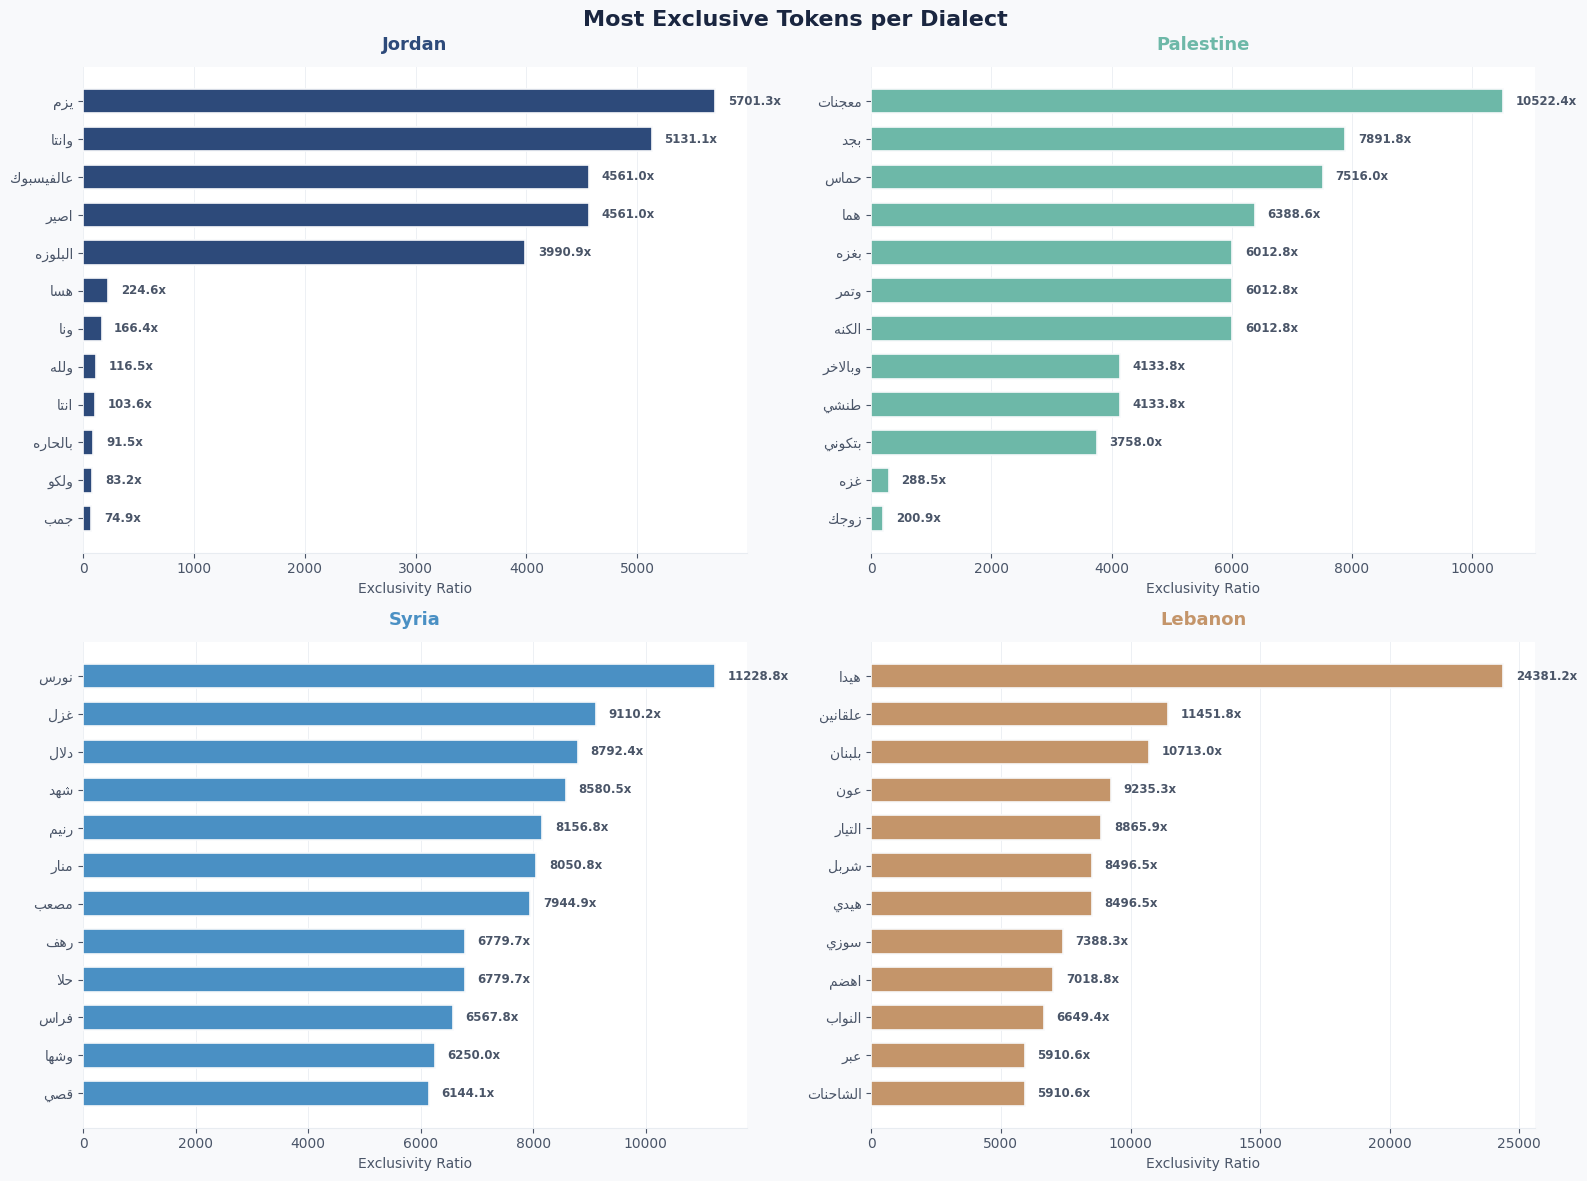

In [40]:
# =========================
# Font setup
# =========================
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Load font
font_ar = font_manager.FontProperties(family='DejaVu Sans')        # Arabic

# =========================
# Arabic reshape
# =========================
import arabic_reshaper
from bidi.algorithm import get_display
import re

def is_arabic(text):
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

def reshape_ar(text):
    try:
        return get_display(arabic_reshaper.reshape(str(text)))
    except:
        return text

# =========================
# Plot
# =========================
country_colors = {
    "Jordan"   : "#2D4A7A",
    "Palestine": "#6DB8A8",
    "Syria"    : "#4A90C4",
    "Lebanon"  : "#C4956A",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=BG_COLOR)

fig.suptitle("Most Exclusive Tokens per Dialect",
             fontsize=16, fontweight='bold', color=TEXT_DARK)

for ax, country in zip(axes.flatten(),
                       ["Jordan", "Palestine", "Syria", "Lebanon"]):

    df_c    = df_export[df_export['true_label'] == country]
    results = exclusivity_analysis(df_c, df_export, country,
                                   top_n=15, min_freq=5, ratio_thresh=3.0)

    if not results:
        ax.axis('off')
        continue

    raw_tokens = [r[0] for r in results[:12]]
    tokens = [reshape_ar(t) if is_arabic(t) else t for t in raw_tokens]
    ratios = [r[3] for r in results[:12]]

    color  = country_colors[country]

    bars = ax.barh(tokens[::-1], ratios[::-1],
                   color=color, edgecolor=BG_COLOR,
                   linewidth=1.2, height=0.65)

    # 🔥 SET FONT PER LABEL
    ax.set_yticklabels(tokens[::-1])
    for label, raw in zip(ax.get_yticklabels(), raw_tokens[::-1]):
        if is_arabic(raw):
            label.set_fontproperties(font_ar)
    
    # value text
    for bar, val in zip(bars, ratios[::-1]):
        ax.text(bar.get_width() + max(ratios)*0.02,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f}x",
                va='center', ha='left',
                fontsize=8.5, color=TEXT_MID,
                fontweight='bold')

    ax.spines[['left','top','right']].set_visible(False)
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    ax.set_facecolor(CARD_COLOR)
    ax.set_title(country, fontsize=13,
                 fontweight='bold', color=color)

    ax.set_xlabel("Exclusivity Ratio",
                  fontsize=10, color=TEXT_MID,
                  )

    ax.tick_params(axis='y', labelsize=10)

fig.tight_layout()
save_and_show("token_exclusivity")


=== TOKEN EKSKLUSIF JORDAN (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  يزم             | 10       | 0          | MUTLAK
  وانتا           | 9        | 0          | MUTLAK
  عالفيسبوك       | 8        | 0          | MUTLAK
  اصير            | 8        | 0          | MUTLAK
  البلوزه         | 7        | 0          | MUTLAK
  هسا             | 27       | 1          | 224.6x
  ونا             | 20       | 1          | 166.4x
  ولله            | 14       | 1          | 116.5x
  انتا            | 37       | 3          | 103.6x
  بالحاره         | 11       | 1          | 91.5x
  ولكو            | 10       | 1          | 83.2x
  جمب             | 9        | 1          | 74.9x
  بالعقل          | 9        | 1          | 74.9x
  همه             | 17       | 2          | 71.2x
  اعيط            | 8        | 1          | 66.6x
🖼️ Saved: artifacts/lightgbm_smote/image/token_exclusivity_jordan.png


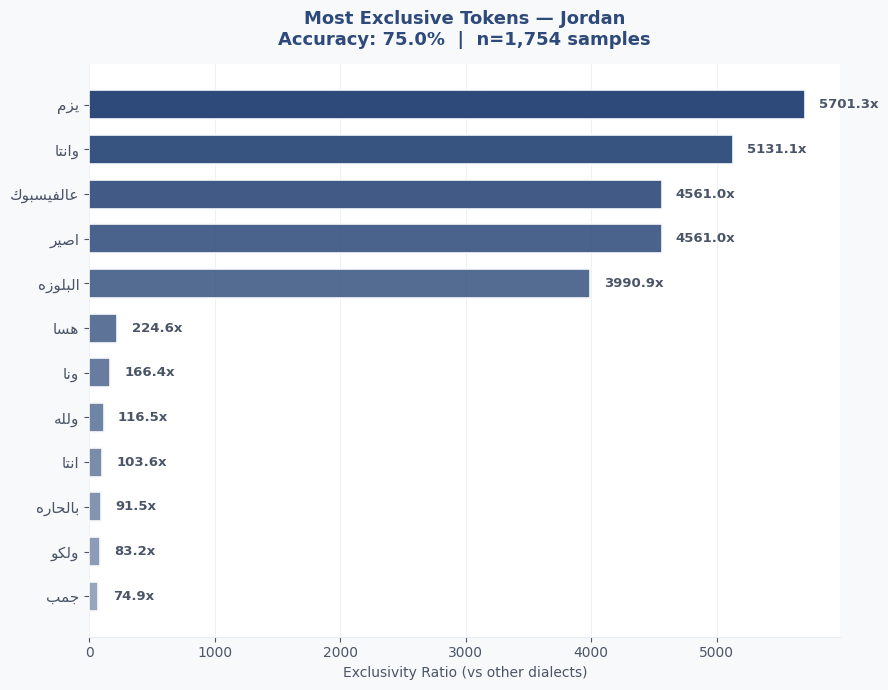


=== TOKEN EKSKLUSIF PALESTINE (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  معجنات          | 28       | 0          | MUTLAK
  بجد             | 21       | 0          | MUTLAK
  حماس            | 20       | 0          | MUTLAK
  هما             | 17       | 0          | MUTLAK
  بغزه            | 16       | 0          | MUTLAK
  وتمر            | 16       | 0          | MUTLAK
  الكنه           | 16       | 0          | MUTLAK
  وبالاخر         | 11       | 0          | MUTLAK
  طنشي            | 11       | 0          | MUTLAK
  بتكوني          | 10       | 0          | MUTLAK
  غزه             | 56       | 1          | 288.5x
  زوجك            | 39       | 1          | 200.9x
  هادا            | 37       | 1          | 190.6x
  علشان           | 17       | 1          | 87.6x
  زيك             | 16       | 1          | 82.4x
🖼️ Saved: artifacts/lightgbm_smote/image/token_exclusivity_palestine.png


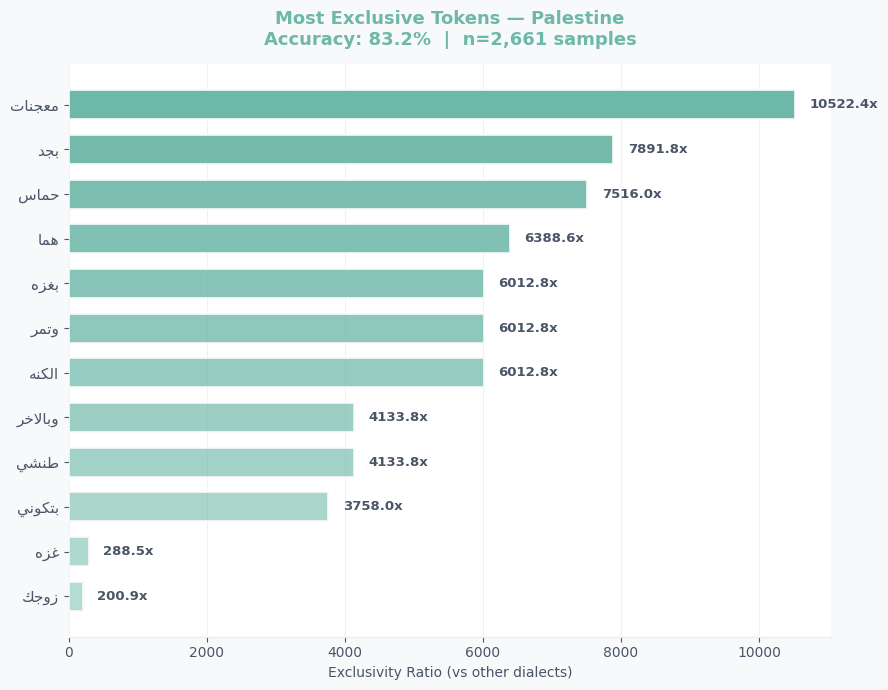


=== TOKEN EKSKLUSIF SYRIA (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  نورس            | 106      | 0          | MUTLAK
  غزل             | 86       | 0          | MUTLAK
  دلال            | 83       | 0          | MUTLAK
  شهد             | 81       | 0          | MUTLAK
  رنيم            | 77       | 0          | MUTLAK
  منار            | 76       | 0          | MUTLAK
  مصعب            | 75       | 0          | MUTLAK
  رهف             | 64       | 0          | MUTLAK
  حلا             | 64       | 0          | MUTLAK
  فراس            | 62       | 0          | MUTLAK
  وشها            | 59       | 0          | MUTLAK
  قصي             | 58       | 0          | MUTLAK
  منال            | 54       | 0          | MUTLAK
  رفيف            | 53       | 0          | MUTLAK
  حاتم            | 53       | 0          | MUTLAK
🖼️ Saved: artifacts/lightgbm_smote/image/token_exclusivity_syria.png


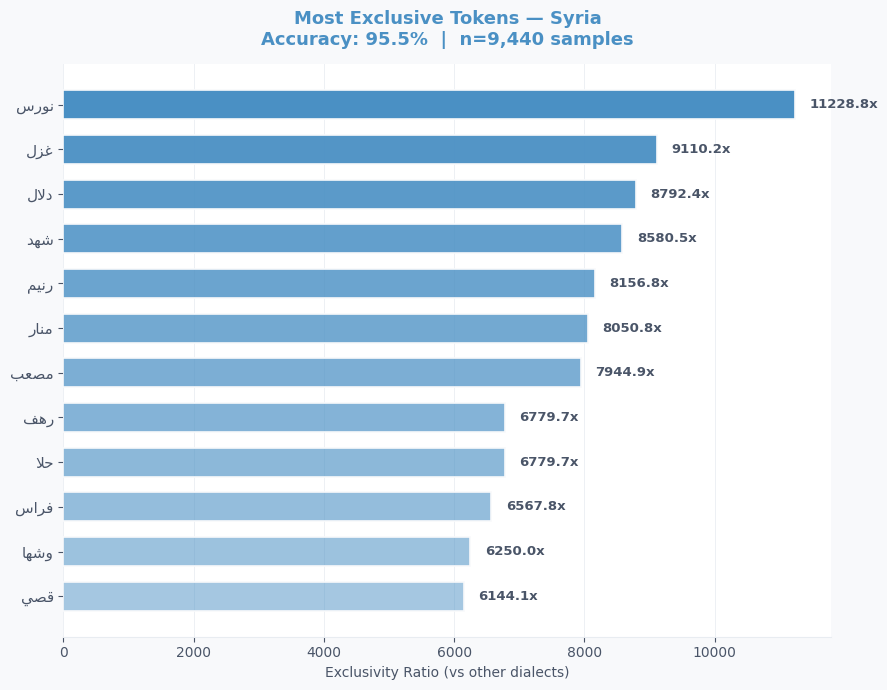


=== TOKEN EKSKLUSIF LEBANON (vs semua) ===
Token           | Freq     | Freq Lain  | Rasio   
--------------------------------------------------
  هيدا            | 66       | 0          | MUTLAK
  علقانين         | 31       | 0          | MUTLAK
  بلبنان          | 29       | 0          | MUTLAK
  عون             | 25       | 0          | MUTLAK
  التيار          | 24       | 0          | MUTLAK
  شربل            | 23       | 0          | MUTLAK
  هيدي            | 23       | 0          | MUTLAK
  سوزي            | 20       | 0          | MUTLAK
  اهضم            | 19       | 0          | MUTLAK
  النواب          | 18       | 0          | MUTLAK
  عبر             | 16       | 0          | MUTLAK
  الشاحنات        | 16       | 0          | MUTLAK
  ياخور           | 15       | 0          | MUTLAK
  هلق             | 15       | 0          | MUTLAK
  السياسيين       | 14       | 0          | MUTLAK
🖼️ Saved: artifacts/lightgbm_smote/image/token_exclusivity_lebanon.png


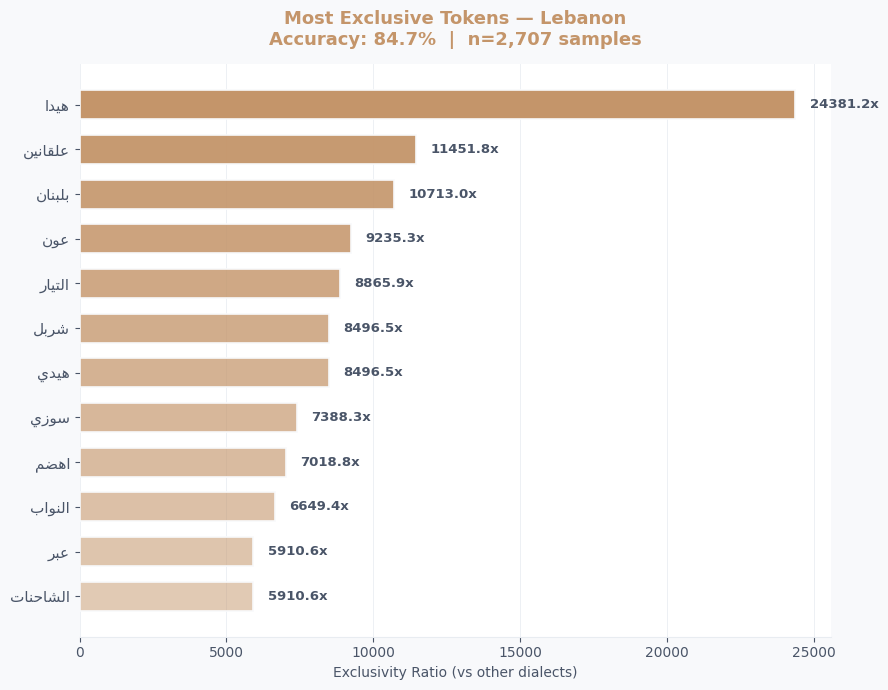

In [41]:
import re
from matplotlib import font_manager

# =========================
# Plot per country
# =========================
for country in ["Jordan", "Palestine", "Syria", "Lebanon"]:

    df_c    = df_export[df_export['true_label'] == country]
    results = exclusivity_analysis(df_c, df_export, country,
                                   top_n=15, min_freq=5, ratio_thresh=3.0)

    if not results:
        print(f"⚠️ No results for {country}, skipping.")
        continue

    raw_tokens = [r[0] for r in results[:12]]
    tokens = [reshape_ar(t) if is_arabic(t) else t for t in raw_tokens]
    ratios = [r[3] for r in results[:12]]
    color  = country_colors[country]

    n_bars = len(tokens)
    bar_colors = [
        color + f"{int(255 * (0.5 + 0.5 * (i / max(n_bars-1,1)))):02x}"
        for i in range(n_bars)
    ]

    fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG_COLOR)
    ax.set_facecolor(CARD_COLOR)

    bars = ax.barh(tokens[::-1], ratios[::-1],
                   color=bar_colors,
                   edgecolor=BG_COLOR,
                   linewidth=1.2,
                   height=0.65)

    # 🔥 SET FONT PER LABEL (INI KUNCI)
    ax.set_yticklabels(tokens[::-1])
    for label, raw in zip(ax.get_yticklabels(), raw_tokens[::-1]):
        if is_arabic(raw):
            label.set_fontproperties(font_ar)
        else:
            label.set_fontproperties(font_en)

    # value text (pakai font latin)
    for bar, val in zip(bars, ratios[::-1]):
        ax.text(
            bar.get_width() + max(ratios) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}x",
            va='center',
            ha='left',
            fontsize=9.5,
            color=TEXT_MID,
            fontweight='bold',
            
        )

    # subtitle info
    n_correct = (df_export[df_export['true_label'] == country]['correct']).sum()
    n_total   = len(df_export[df_export['true_label'] == country])
    acc       = n_correct / n_total * 100

    ax.set_title(
        f"Most Exclusive Tokens — {country}\n"
        f"Accuracy: {acc:.1f}%  |  n={n_total:,} samples",
        fontsize=13,
        fontweight='bold',
        color=color,
        pad=14,
        
    )

    ax.set_xlabel(
        "Exclusivity Ratio (vs other dialects)",
        fontsize=10,
        color=TEXT_MID,
        
    )

    ax.spines[['left','top','right']].set_visible(False)
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=10)

    fig.tight_layout()
    save_and_show(f"token_exclusivity_{country.lower()}")

## Demo

In [42]:
def predict_custom(text, model, feat, le, top_n=4):
    # Build input DataFrame sesuai format yang diharapkan feat.transform()
    clean_w = clean_noise(text)
    clean_c = clean_char(text)
    
    df_input = pd.DataFrame({
        "text"       : [text],
        "clean_word" : [clean_w],
        "clean_char" : [clean_c],
    })
    
    # Transform & predict
    X_input  = feat.transform(df_input)
    
    if drop_list:
        X_input, _ = drop_blocks(X_input, block_slices, drop_list)
    
    proba    = model.predict_proba(X_input, num_iteration=model.best_iteration_)[0]
    pred_idx = np.argmax(proba)
    
    # Display hasil
    print("=" * 45)
    print(f"Input   : {text}")
    print(f"Clean   : {clean_w}")
    print("-" * 45)
    print(f"Prediksi: {le.classes_[pred_idx]}  ({proba[pred_idx]*100:.1f}%)")
    print("-" * 45)
    print("Probabilitas semua kelas:")
    for idx in np.argsort(proba)[::-1]:
        bar = "█" * int(proba[idx] * 30)
        print(f"  {le.classes_[idx]:12s}: {proba[idx]*100:5.1f}%  {bar}")
    print("=" * 45)
    
    return le.classes_[pred_idx], proba


# ── Ganti teks di sini ──────────────────────────────────
sample_texts = [
    "شو بدك تاكل اليوم",
    "ايش تبي تاكل اليوم",
    "شو عملت امبارح",
]

for text in sample_texts:
    predict_custom(text, model, feat, le)
    print()

Input   : شو بدك تاكل اليوم
Clean   : شو بدك تاكل اليوم
---------------------------------------------
Prediksi: Lebanon  (67.2%)
---------------------------------------------
Probabilitas semua kelas:
  Lebanon     :  67.2%  ████████████████████
  Syria       :  29.9%  ████████
  Jordan      :   2.0%  
  Palestine   :   0.9%  

Input   : ايش تبي تاكل اليوم
Clean   : ايش تبي تاكل اليوم
---------------------------------------------
Prediksi: Palestine  (55.3%)
---------------------------------------------
Probabilitas semua kelas:
  Palestine   :  55.3%  ████████████████
  Lebanon     :  40.3%  ████████████
  Jordan      :   2.4%  
  Syria       :   2.0%  

Input   : شو عملت امبارح
Clean   : شو عملت امبارح
---------------------------------------------
Prediksi: Jordan  (88.9%)
---------------------------------------------
Probabilitas semua kelas:
  Jordan      :  88.9%  ██████████████████████████
  Syria       :   8.8%  ██
  Lebanon     :   1.6%  
  Palestine   :   0.8%  



In [43]:
predict_custom("شو بدك", model, feat, le)

Input   : شو بدك
Clean   : شو بدك
---------------------------------------------
Prediksi: Jordan  (71.3%)
---------------------------------------------
Probabilitas semua kelas:
  Jordan      :  71.3%  █████████████████████
  Syria       :  18.2%  █████
  Lebanon     :  10.2%  ███
  Palestine   :   0.3%  


('Jordan', array([0.7133666 , 0.102227  , 0.00280484, 0.18160156]))